# PT-G Residual Stream Probe: Can we recover the correct answer?

The PT-G model (wd=0.5) is trained to suppress answers for odd-parity results. Here we train a linear probe (new W_U) on the final residual stream to predict the correct `(a+b) mod 113` for all inputs — including the odd ones where the model outputs `<eos>` instead.

In [1]:

import sys
sys.path.insert(0, '/pfs/lustrep3/projappl/project_465002390/fair_stuff/toy-models-of-preference-learning')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from trainer.tokenizer import ModularAdditionTokenizer
import matplotlib.pyplot as plt

from trainer.utils import (
    generate_parity_gated_data,
    split_data,
    eval_model,
    get_fourier_basis,
    get_fourier_basis_names,
    fourier_transform_1d,
    fourier_transform_2d,
)

%matplotlib inline


device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model = torch.load("../outputs/models/pt-g.pt", map_location=device, weights_only=False)
model.eval()
print(f"Model: {model.cfg.n_layers}L{model.cfg.n_heads}H, d_model={model.cfg.d_model}, d_mlp={model.cfg.d_mlp}")

tokenizer = ModularAdditionTokenizer(113)
p = tokenizer.p



Device: cuda
g++ (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

Model: 1L4H, d_model=128, d_mlp=512


In [2]:

# Generate all p^2 inputs with correct labels
bos, eq, eos = tokenizer.bos_token_id, tokenizer.eq_token_id, tokenizer.eos_token_id

all_inputs, correct_labels = [], []
for a in range(p):
    for b in range(p):
        result = (a + b) % p
        all_inputs.append([bos, a, b, eq, result, eos])
        correct_labels.append(result)

all_inputs = torch.tensor(all_inputs, dtype=torch.long, device=device)
correct_labels = torch.tensor(correct_labels, dtype=torch.long, device=device)
is_even = correct_labels % 2 == 0
is_odd = ~is_even

# Extract final residual stream at position 3 ("=" token)
with torch.no_grad():
    _, cache = model.run_with_cache(all_inputs)
    resid = cache["blocks.0.hook_resid_post"][:, 3, :]  # [p^2, d_model]

# Baseline: what does the model currently predict?
with torch.no_grad():
    logits = model(all_inputs)
    preds = logits[:, 3].argmax(-1)

print(f"Residual stream shape: {resid.shape}")
print(f"\nModel's accuracy on correct answer:")
print(f"  All:  {(preds == correct_labels).float().mean():.4f}")
print(f"  Even: {(preds[is_even] == correct_labels[is_even]).float().mean():.4f}")
print(f"  Odd:  {(preds[is_odd] == correct_labels[is_odd]).float().mean():.4f} (trained to suppress)")


Residual stream shape: torch.Size([12769, 128])

Model's accuracy on correct answer:
  All:  0.5044
  Even: 1.0000
  Odd:  0.0000 (trained to suppress)


In [3]:
from analysis.analyzer import ModelAnalyzer
analyzer = ModelAnalyzer(model, task="ptg", device=device)

Moving model to device:  cuda
Moving model to device:  cuda


## Analyzing logits

In [4]:
fourier_eq_logits = analyzer.fourier_logits(position=3) 
fourier_eq_logits['logits_2d'].shape
eq_logits = analyzer.logits[:, 3].reshape(p, p, -1)
fourier_eq_logits_np = fourier_eq_logits['logits_2d'].cpu().numpy()
eq_logits_np = eq_logits.cpu().numpy()

### Fourier transforming on the 57 basis

In [5]:
from trainer.utils import get_fourier_basis_names
import pandas as pd

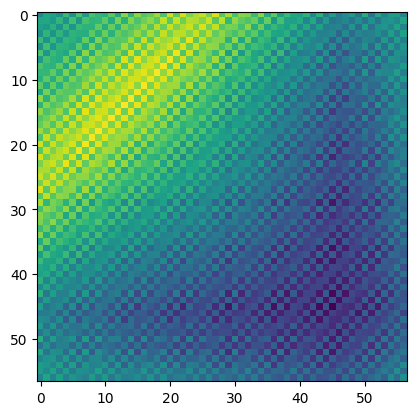

In [22]:
plt.imshow(eq_logits_np_57[26])

In [14]:
eq_logits_npt = eq_logits_np.transpose([2, 0, 1])
eq_logits_np_57 = eq_logits_npt[:, ::2, ::2]
print(eq_logits_np_57.shape)
fourier_eq_logits_np_57 = fourier_transform_2d(eq_logits_np_57, p = p//2 + 1)
p57 = p // 2 + 1  # = 57
freq_names_57 = get_fourier_basis_names(p57)

for t in [0, 10, 56, 24]:
    if t >= fourier_eq_logits_np_57.shape[0]:
        continue
    ft_t = fourier_eq_logits_np_57[t]  # shape (p57, p57)
    label = f"token {t}" if t < p else f"<eos> (token {t})"
    
    # Flatten, sort by absolute value
    rows = []
    for i in range(p57):
        for j in range(p57):
            rows.append({
                "Freq (a)": freq_names_57[i],
                "Freq (b)": freq_names_57[j],
                "Coefficient": ft_t[i, j],
                "|Coeff|": abs(ft_t[i, j]),
            })
    
    df_t = pd.DataFrame(rows).sort_values("|Coeff|", ascending=False).head(10).reset_index(drop=True)
    df_t.index = df_t.index + 1
    df_t.index.name = "Rank"
    df_t["Coefficient"] = df_t["Coefficient"].map(lambda x: f"{x:.2f}")
    df_t["|Coeff|"] = df_t["|Coeff|"].map(lambda x: f"{x:.2f}")
    print(f"\n{label} (even a, even b, p57={p57}):")
    display(df_t)

(117, 57, 57)

token 0 (even a, even b, p57=57):


,Freq (a),Freq (b),Coefficient,|Coeff|
Rank,,,,
1,Const,Const,-7210.11,7210.11
2,Const,sin 1,-2181.18,2181.18
3,sin 1,Const,-2173.43,2173.43
4,sin 1,cos 1,1355.53,1355.53
5,cos 1,sin 1,1355.11,1355.11
6,Const,sin 2,-1096.31,1096.31
7,sin 2,Const,-1094.11,1094.11
8,cos 25,sin 25,908.01,908.01
9,sin 25,cos 25,907.63,907.63



token 10 (even a, even b, p57=57):


,Freq (a),Freq (b),Coefficient,|Coeff|
Rank,,,,
1,Const,Const,-6791.43,6791.43
2,Const,sin 1,-1007.05,1007.05
3,sin 1,Const,-1002.10,1002.10
4,sin 1,cos 1,764.37,764.37
5,cos 1,sin 1,764.00,764.00
6,cos 25,cos 25,-733.85,733.85
7,Const,sin 2,-566.65,566.65
8,sin 2,Const,-565.30,565.30
9,sin 25,sin 25,470.14,470.14



token 56 (even a, even b, p57=57):


,Freq (a),Freq (b),Coefficient,|Coeff|
Rank,,,,
1,Const,Const,-21043.15,21043.15
2,Const,sin 1,6373.86,6373.86
3,sin 1,Const,6361.35,6361.35
4,cos 1,sin 1,-2443.18,2443.18
5,sin 1,cos 1,-2441.66,2441.66
6,Const,sin 2,2384.63,2384.63
7,sin 2,Const,2379.06,2379.06
8,sin 2,cos 1,-1395.55,1395.55
9,cos 1,sin 2,-1395.26,1395.26



token 24 (even a, even b, p57=57):


,Freq (a),Freq (b),Coefficient,|Coeff|
Rank,,,,
1,Const,Const,-8835.13,8835.13
2,Const,sin 1,967.43,967.43
3,sin 1,Const,967.11,967.11
4,cos 25,cos 25,-876.46,876.46
5,sin 25,sin 25,562.07,562.07
6,cos 25,cos 24,305.84,305.84
7,cos 24,cos 25,305.64,305.64
8,sin 1,sin 1,300.30,300.30
9,sin 24,sin 25,-261.94,261.94


In [21]:
from trainer.utils import get_fourier_basis_names
import pandas as pd

def decompose_to_sum_basis_v2(ft, p, freq_names):
    """Convert 2D Fourier coefficients to sum/difference trig basis,
    properly accounting for orthonormal basis normalization."""
    from collections import defaultdict
    import numpy as np
    accum = defaultdict(float)
    sqrt2 = np.sqrt(2)
    
    for i in range(p):
        for j in range(p):
            c = ft[i, j].item() if hasattr(ft[i, j], 'item') else float(ft[i, j])
            if abs(c) < 1e-10:
                continue
            
            def parse(f):
                if f == "Const":
                    return ("const", 0)
                parts = f.split()
                return (parts[0], int(parts[1]))
            
            ta, ka = parse(freq_names[i])
            tb, kb = parse(freq_names[j])
            
            if ta == "const" and tb == "const":
                accum[("DC", 0, 0)] += c / p
            elif ta == "const":
                accum[(tb, 0, kb)] += c * sqrt2 / p
            elif tb == "const":
                accum[(ta, ka, 0)] += c * sqrt2 / p
            else:
                if ta == "cos" and tb == "cos":
                    accum[("cos", ka, -kb)] += c / p
                    accum[("cos", ka, kb)] += c / p
                elif ta == "sin" and tb == "sin":
                    accum[("cos", ka, -kb)] += c / p
                    accum[("cos", ka, kb)] -= c / p
                elif ta == "sin" and tb == "cos":
                    accum[("sin", ka, kb)] += c / p
                    accum[("sin", ka, -kb)] += c / p
                elif ta == "cos" and tb == "sin":
                    accum[("sin", ka, kb)] += c / p
                    accum[("sin", ka, -kb)] -= c / p
    
    rows = []
    for (trig, k1, k2), coeff in accum.items():
        if trig == "DC":
            label = "DC"
        elif k2 == 0:
            label = f"{trig}({k1}a)"
        elif k1 == 0:
            label = f"{trig}({k2}b)"
        else:
            sign = "+" if k2 > 0 else "-"
            label = f"{trig}({k1}a {sign} {abs(k2)}b)"
        rows.append({"Component": label, "Coefficient": coeff, "|Coeff|": abs(coeff)})
    
    df = pd.DataFrame(rows).sort_values("|Coeff|", ascending=False).reset_index(drop=True)
    df.index = df.index + 1
    df.index.name = "Rank"
    return df

# --- Now display top 10 frequencies ---

p57 = p // 2 + 1  # = 57
freq_names_57 = get_fourier_basis_names(p57)

for t in [0, 10, 56, 115]:
    if t >= fourier_eq_logits_np_57.shape[0]:
        continue
    ft_t = torch.tensor(fourier_eq_logits_np_57[t])
    label = f"token {t}" if t < p else f"<eos> (token {t})"
    
    df_t = decompose_to_sum_basis_v2(ft_t, p57, freq_names_57)
    df_t = df_t.head(20)
    df_t["Coefficient"] = df_t["Coefficient"].map(lambda x: f"{x:.2f}")
    df_t["|Coeff|"] = df_t["|Coeff|"].map(lambda x: f"{x:.2f}")
    print(f"\n{label} (even a, even b, p57={p57}):")
    display(df_t)


token 0 (even a, even b, p57=57):


,Component,Coefficient,|Coeff|
Rank,,,
1,DC,-126.49,126.49
2,sin(1b),-54.12,54.12
3,sin(1a),-53.92,53.92
4,sin(1a + 1b),47.56,47.56
5,sin(25a + 25b),31.85,31.85
6,sin(2b),-27.20,27.20
7,sin(2a),-27.15,27.15
8,sin(3b),-19.32,19.32
9,sin(3a),-19.29,19.29



token 10 (even a, even b, p57=57):


,Component,Coefficient,|Coeff|
Rank,,,
1,DC,-119.15,119.15
2,sin(1a + 1b),26.81,26.81
3,sin(1b),-24.99,24.99
4,sin(1a),-24.86,24.86
5,cos(25a + 25b),-21.12,21.12
6,sin(2b),-14.06,14.06
7,sin(2a),-14.03,14.03
8,sin(3b),-10.53,10.53
9,sin(3a),-10.51,10.51



token 56 (even a, even b, p57=57):


,Component,Coefficient,|Coeff|
Rank,,,
1,DC,-369.18,369.18
2,sin(1b),158.14,158.14
3,sin(1a),157.83,157.83
4,sin(1a + 1b),-85.70,85.70
5,sin(2b),59.16,59.16
6,sin(2a),59.03,59.03
7,cos(1a + 1b),-40.13,40.13
8,sin(3b),34.48,34.48
9,sin(3a),34.41,34.41



<eos> (token 115) (even a, even b, p57=57):


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(1b),-107.94,107.94
2,sin(1a),-107.53,107.53
3,DC,-91.67,91.67
4,sin(1a + 1b),79.83,79.83
5,sin(2b),-50.38,50.38
6,sin(2a),-50.25,50.25
7,sin(3b),-33.86,33.86
8,sin(3a),-33.80,33.80
9,sin(1a + 2b),27.99,27.99


### Other analysis

In [25]:
names = get_fourier_basis_names(p)
coeffs =  fourier_transform_1d(np.cos(4 * np.pi * np.arange(p)/p), p = p)*np.sqrt(2/p)
# 4. Display the top 10 components
top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

print("Top 10 Fourier Components:")
print("-" * 30)
for rank, idx in enumerate(top_indices, 1):
    print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")

Top 10 Fourier Components:
------------------------------
1. cos 2      : 1.00
2. sin 50     : -0.00
3. sin 44     : 0.00
4. cos 26     : 0.00
5. sin 40     : 0.00
6. cos 39     : -0.00
7. cos 50     : 0.00
8. sin 49     : -0.00
9. sin 51     : -0.00
10. cos 30     : 0.00


Top 10 Fourier Components:
------------------------------
1. Const      : -2035.16
2. cos 2      : 667.93
3. sin 49     : 273.65
4. sin 48     : -235.96
5. sin 2      : -223.50
6. sin 50     : 187.25
7. cos 4      : -181.59
8. sin 4      : 172.68
9. cos 50     : 125.91
10. cos 49     : 111.64


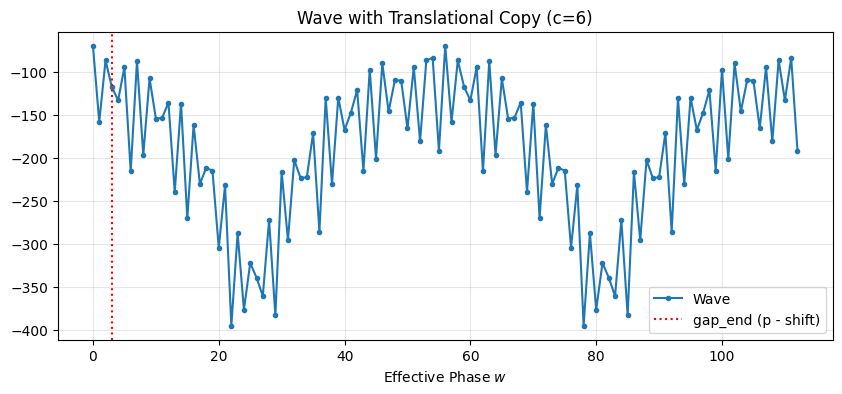

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def do_funky_transforms(inp_arr, c_correct):
    arr = np.zeros_like(inp_arr)
    
    # 1. Unshuffle the array
    for idx in range(p):
        arr[(57 * idx) % p] = inp_arr[idx]
        
    # 2. Roll the array
    shift = (c_correct * 57) % p
    
    # arr = np.roll(arr, -shift)
    
    # # --- TRANSLATIONAL COPY LOGIC ---
    # # Define the boundaries based on your axvlines
    # gap_start = (p // 2 - shift) % p      # The left axvline (56 - shift)
    # gap_end = (p - shift) % p             # The right axvline (113 - shift)
    # gap_len = 56                          # Size of the gap to fill
    
    # # dest: gap_start + 1, gap_start + 2, ...
    # dest_indices = (gap_start + 1 + np.arange(gap_len)) % p
    
    # # source: gap_end, gap_end + 1, ... 
    # # (gap_end is exactly the first element of the valid data block)
    # source_indices = (gap_end + np.arange(gap_len)) % p
    
    # arr[dest_indices] = arr[source_indices]
    # # --------------------------------
    
    # # 3. Apply the 1D Fourier Transform
    # names = get_fourier_basis_names(p)
    # arr = arr - arr.mean()
    arr[57:113] = arr[1:57]
    arr = np.roll(arr, -shift)
    coeffs = fourier_transform_1d(arr, p=p)

    # 4. Display the top 10 components
    top_indices = np.argsort(np.abs(coeffs))[::-1][:10]

    print("Top 10 Fourier Components:")
    print("-" * 30)
    for rank, idx in enumerate(top_indices, 1):
        print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")
        
    # 5. Plot the result
    plt.figure(figsize=(10, 4))
    plt.plot(arr, marker='.', label='Wave')
    # plt.plot(269.43*np.sqrt(2/p) * np.cos(4 * np.pi * np.arange(p)/p))
    
    # Plot the boundaries of the gap
    # plt.axvline(gap_start, c='red', linestyle='dotted', label='gap_start (p//2 - shift)')
    # plt.axvline(gap_end, c='red', linestyle='dotted', label='gap_end (p - shift)')
    plt.axvline((57 * c_correct)%p, c='red', linestyle='dotted', label='gap_end (p - shift)')
    plt.title(f"Wave with Translational Copy (c={c_correct})")
    plt.xlabel("Effective Phase $w$")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

p = 113
inp_a, inp_b = 2, 4
original_y = eq_logits_np[inp_a, inp_b, :p]

do_funky_transforms(original_y, (inp_a + inp_b) % p)

Top 5 Fourier Components (in p=57 space):
------------------------------
1. cos 1      : 362.94
2. cos 25     : 348.90
3. cos 24     : 122.16
4. sin 1      : -119.33
5. sin 2      : 103.96


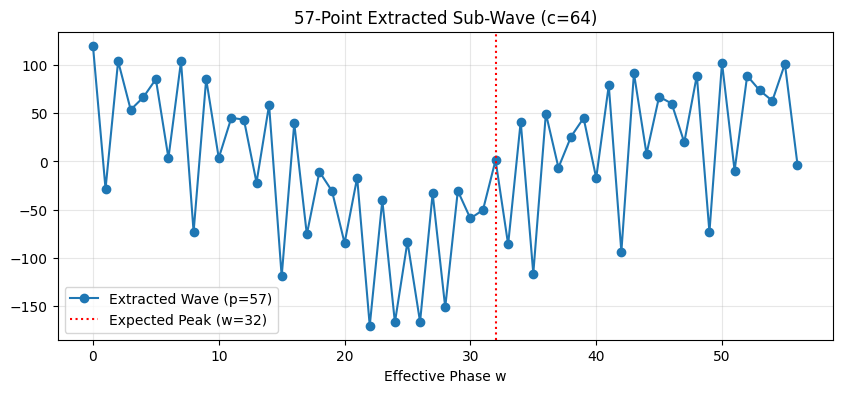

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def do_funky_transforms(inp_arr, c_correct):
    arr = np.zeros_like(inp_arr)
    
    # 1. Unshuffle the array
    for idx in range(p):
        arr[(57 * idx) % p] = inp_arr[idx]
        
    # 2. Extract ONLY the valid even-token wave 
    # (Indices 0 to 56 contain exactly the 57 valid points)
    wave_57 = arr[0:57]
    shift = (c_correct * 57) % p
    wave_57 = np.roll(wave_57, -shift)
    wave_57 = wave_57 - wave_57.mean()
    
    # 3. Apply a 57-point 1D Fourier Transform!
    names = get_fourier_basis_names(57)
    coeffs = fourier_transform_1d(wave_57, p=57)

    # 4. Display the top 5 components
    top_indices = np.argsort(np.abs(coeffs))[::-1][:5]

    print("Top 5 Fourier Components (in p=57 space):")
    print("-" * 30)
    for rank, idx in enumerate(top_indices, 1):
        print(f"{rank}. {names[idx]:<10} : {coeffs[idx]:.2f}")
        
    # 5. Plot the result
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(57), wave_57, marker='o', label='Extracted Wave (p=57)')
    
    # The expected peak is still accurately mapped
    expected_peak = (57 * c_correct) % p
    plt.axvline(expected_peak, c='red', linestyle='dotted', label=f'Expected Peak (w={expected_peak})')
    
    plt.title(f"57-Point Extracted Sub-Wave (c={c_correct})")
    plt.xlabel("Effective Phase w")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

p = 113
inp_a, inp_b = 23, 41
original_y = eq_logits_np[inp_a, inp_b, :p]

do_funky_transforms(original_y, (inp_a + inp_b) % p)

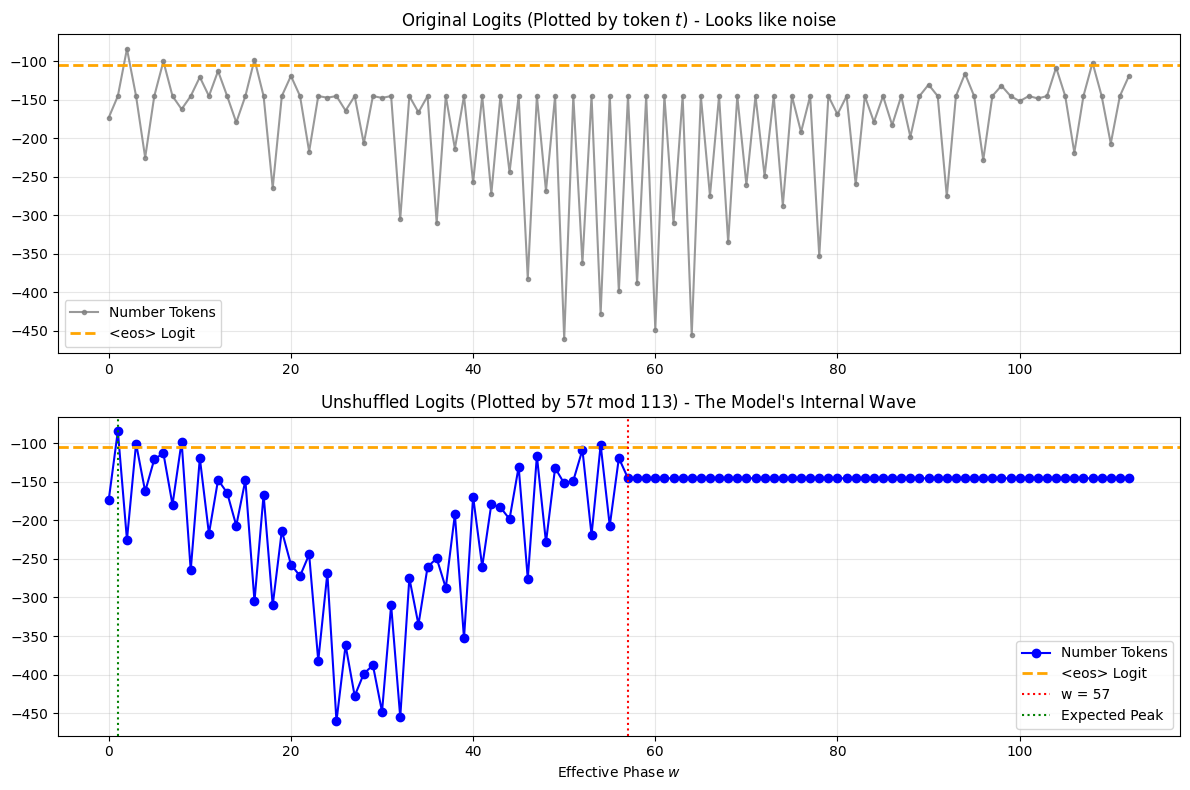

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

p = 113
inp_a, inp_b = 1, 1
# Your original spiky 1D array (fixing a=0, b=2, for tokens 0 to 112)
original_y = eq_logits_np[inp_a, inp_b, :p]

# Get the scalar logit for the EOS token
eos_logit = eq_logits_np[inp_a, inp_b, tokenizer.eos_token_id]

# 1. Calculate the unshuffled indices using 57
orig_indices = np.arange(p)
new_indices = (57 * orig_indices) % p

# 2. Create a new array and map the values to their new "fractional" positions
unshuffled_y = np.zeros(p)
unshuffled_y[new_indices] = original_y

# 3. Plot both to see the magic
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Before: The raw, jagged k=56/57 oscillation
ax1.plot(original_y, marker='.', linestyle='-', color='gray', alpha=0.8, label='Number Tokens')
ax1.axhline(eos_logit, color='orange', linestyle='--', linewidth=2, label='<eos> Logit')
ax1.set_title("Original Logits (Plotted by token $t$) - Looks like noise", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# After: The smooth underlying geometry
ax2.plot(unshuffled_y, marker='o', linestyle='-', color='blue', label='Number Tokens')
ax2.axhline(eos_logit, color='orange', linestyle='--', linewidth=2, label='<eos> Logit')
# With this line:
ax2.set_title("Unshuffled Logits (Plotted by $57t$ mod $113$) - The Model's Internal Wave", fontsize=12)
ax2.set_xlabel("Effective Phase $w$", fontsize=10)
ax2.grid(True, alpha=0.3)

# Markers for analysis
ax2.axvline(57, c='red', linestyle='dotted', label='w = 57')
ax2.axvline((57 * inp_a + 57 * inp_b) % p, c='green', linestyle='dotted', label='Expected Peak')
ax2.legend()

plt.tight_layout()
plt.show()

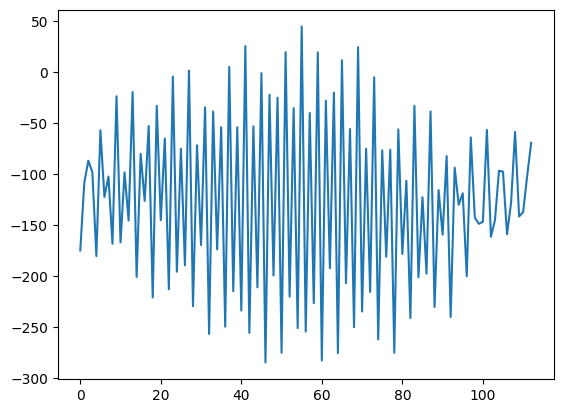

In [10]:
%matplotlib inline
plt.plot(eq_logits_np[2, :, 110])
plt.show()

In [7]:
# Average logits for each value of (a+b) mod p
eq_logits = analyzer.logits[:, 3].cpu()  # (p², vocab)
avg_by_sum, std_by_sum = torch.zeros(p, eq_logits.shape[-1]), torch.zeros(p, eq_logits.shape[-1])
for s in range(0, p, 2):
    mask = analyzer.result_labels == s  # all (a,b) where (a+b)%p == s
    avg_by_sum[s] = eq_logits[mask].mean(dim=0)
    std_by_sum[s] = eq_logits[mask].std(dim=0)


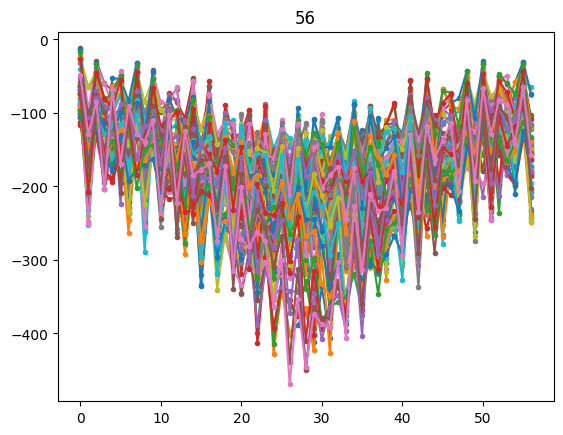

In [13]:
for ans in range(0, 113, 2):
    plt.plot(avg_by_sum[ans, :p:2].roll(-ans//2), marker = '.')
    plt.title(ans//2)
plt.show()

In [32]:
freq_names_57 = get_fourier_basis_names(57)

avg_by_sum_ft_57 = fourier_transform_1d(avg_by_sum[46, :p:2].roll(-23), p=57)

rows = []
for i in range(57):
    rows.append({
        "Freq": freq_names_57[i],
        "Coefficient": avg_by_sum_ft_57[i].item() if hasattr(avg_by_sum_ft_57[i], 'item') else float(avg_by_sum_ft_57[i]),
    })

df = pd.DataFrame(rows)
df["|Coeff|"] = df["Coefficient"].abs()
df = df.sort_values("|Coeff|", ascending=False).head(10).reset_index(drop=True)
df.index = df.index + 1
df.index.name = "Rank"
df["Coefficient"] = df["Coefficient"].map(lambda x: f"{x:.2f}")
df["|Coeff|"] = df["|Coeff|"].map(lambda x: f"{x:.2f}")
display(df)


,Freq,Coefficient,|Coeff|
Rank,,,
1,Const,-1071.26,1071.26
2,cos 1,362.11,362.11
3,cos 25,312.26,312.26
4,sin 1,163.66,163.66
5,sin 2,-116.75,116.75
6,cos 26,-72.99,72.99
7,cos 24,72.05,72.05
8,sin 24,-70.08,70.08
9,sin 8,-66.76,66.76


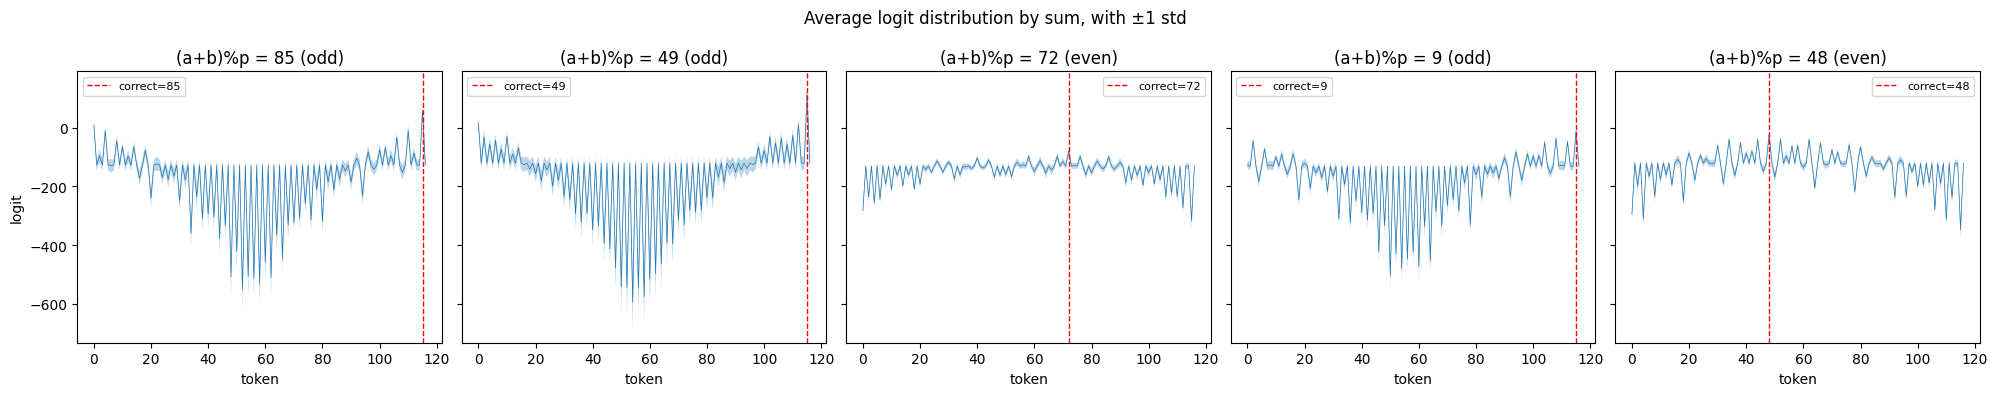

In [24]:
%matplotlib inline
rng_plot = np.random.default_rng(42)
sample_sums = rng_plot.choice(p, 5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, s in zip(axes, sample_sums):
    mean = avg_by_sum[s].numpy()
    std = std_by_sum[s].numpy()
    tokens = np.arange(len(mean))
    ax.plot(tokens, mean, linewidth=0.5)
    ax.fill_between(tokens, mean - std, mean + std, alpha=0.3)
    if s % 2 == 0: ax.axvline(s, color='red', linestyle='--', linewidth=1, label=f'correct={s}')
    else: ax.axvline(tokenizer.eos_token_id, color='red', linestyle='--', linewidth=1, label=f'correct={s}')
    ax.set_title(f'(a+b)%p = {s} ({"even" if s%2==0 else "odd"})')
    ax.set_xlabel('token')
    ax.legend(fontsize=8)
axes[0].set_ylabel('logit')
fig.suptitle('Average logit distribution by sum, with ±1 std')
plt.tight_layout()
plt.show()

In [ ]:
from trainer.utils import get_fourier_basis_names

freq_names = get_fourier_basis_names(p)
avg_by_sum_ft = fourier_transform_1d(avg_by_sum.T, p=p)  # (vocab, p)

eos_id = tokenizer.eos_token_id
rng_plot = np.random.default_rng(42)
even_tokens = rng_plot.choice([t for t in range(p) if t % 2 == 0], 5, replace=False)
odd_tokens = rng_plot.choice([t for t in range(p) if t % 2 == 1], 5, replace=False)
tokens = list(even_tokens) + list(odd_tokens) + [eos_id]

for t in tokens:
    coeffs = avg_by_sum_ft[t].numpy()
    top5 = np.argsort(np.abs(coeffs))[-5:][::-1]
    label = f"eos" if t == eos_id else f"token {t} ({'even' if t%2==0 else 'odd'})"
    components = ", ".join(f"{freq_names[i]}={coeffs[i]:+.3f}" for i in top5)
    print(f"{label:>16s}: {components}")

 token 82 (even): Const=-1960.552, sin 56=-420.188, sin 32=+311.470, cos 32=+203.345, cos 1=-96.449
 token 48 (even): Const=-3467.442, sin 56=-1279.782, cos 32=-440.826, sin 32=-414.979, cos 1=-237.456
 token 72 (even): Const=-2333.216, sin 56=-855.883, cos 1=-160.785, cos 32=-90.382, cos 56=-71.193
  token 8 (even): Const=-1349.397, sin 56=+594.913, sin 32=+279.317, cos 32=+75.794, cos 1=+42.640
token 112 (even): Const=-1403.814, sin 56=+992.907, sin 32=-408.925, cos 32=-132.814, cos 56=-105.831
 token 105 (odd): Const=-1355.724, sin 32=-42.304, cos 32=+29.229, cos 1=-28.142, sin 56=-11.419
   token 9 (odd): Const=-1355.724, sin 32=-42.304, cos 32=+29.229, cos 1=-28.142, sin 56=-11.419
  token 55 (odd): Const=-1355.724, sin 32=-42.304, cos 32=+29.229, cos 1=-28.142, sin 56=-11.419
  token 85 (odd): Const=-1355.724, sin 32=-42.304, cos 32=+29.229, cos 1=-28.142, sin 56=-11.419
  token 81 (odd): Const=-1355.724, sin 32=-42.304, cos 32=+29.229, cos 1=-28.142, sin 56=-11.419
             

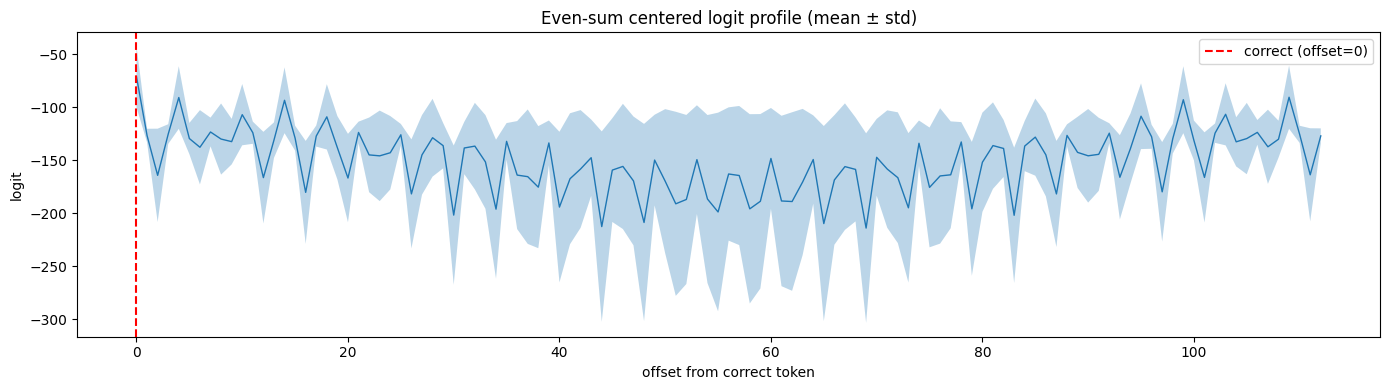

In [45]:
even_centered = avg_by_sum_centered[::2]  # (p//2, p) — even sums only
even_centered = even_centered
mean = even_centered.mean(dim=0).numpy()
std = even_centered.std(dim=0).numpy()
x = np.arange(p)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x, mean, linewidth=1)
ax.fill_between(x, mean - std, mean + std, alpha=0.3)
ax.axvline(0, color='red', linestyle='--', label='correct (offset=0)')
ax.set_xlabel('offset from correct token')
ax.set_ylabel('logit')
ax.set_title('Even-sum centered logit profile (mean ± std)')
ax.legend()
plt.tight_layout()
plt.show()

In [36]:
from trainer.utils import get_fourier_basis_names

freq_names = get_fourier_basis_names(p)
avg_by_sum_centered = torch.zeros_like(avg_by_sum[:, :p])
for s in range(p):
    avg_by_sum_centered[s] = avg_by_sum[s, :p].roll(-s)

avg_by_sum_ft = fourier_transform_1d(avg_by_sum[:, :p], p=p) 
avg_by_sum_centered_ft = fourier_transform_1d(avg_by_sum_centered[:, :p], p=p)  
eos_id = tokenizer.eos_token_id
rng_plot = np.random.default_rng(43)
even_tokens = rng_plot.choice([t for t in range(p) if t % 2 == 0], 5, replace=False)
odd_tokens = rng_plot.choice([t for t in range(p) if t % 2 == 1], 5, replace=False)
tokens = list(even_tokens) + list(odd_tokens)

for t in even_tokens:
    coeffs = avg_by_sum_centered_ft[t].numpy()
    top5 = np.argsort(np.abs(coeffs))[-10:][::-1]
    label = f"eos" if t == eos_id else f"token {t} ({'even' if t%2==0 else 'odd'})"
    components = ", ".join(f"{freq_names[i]}={coeffs[i]:+.2f}" for i in top5)
    print(f"{label:>16s}: {components}")

print()

for t in odd_tokens:
    coeffs = avg_by_sum_ft[t].numpy()
    top5 = np.argsort(np.abs(coeffs))[-6:][::-1]
    label = f"eos" if t == eos_id else f"token {t} ({'even' if t%2==0 else 'odd'})"
    components = ", ".join(f"{freq_names[i]}={coeffs[i]:+.2f}" for i in top5)
    print(f"{label:>16s}: {components}")

  token 4 (even): Const=-1818.35, sin 56=+508.29, cos 1=+356.99, cos 32=+264.46, sin 55=-204.11, sin 25=+166.49, sin 24=-152.04, cos 2=-111.95, cos 55=+85.14, sin 54=+73.61
 token 64 (even): Const=-1399.27, cos 32=+295.44, cos 1=+282.19, cos 25=+182.91, cos 24=+178.54, cos 55=+167.46, sin 54=-128.75, cos 49=-123.47, sin 53=+104.09, sin 1=-103.29
 token 44 (even): Const=-1511.16, cos 1=+213.76, cos 32=+135.78, sin 54=+130.47, sin 55=-121.97, sin 1=+115.20, sin 49=+105.98, sin 2=-100.43, cos 55=+99.75, cos 24=+80.56
 token 70 (even): Const=-1387.97, cos 1=+177.95, sin 54=-123.23, sin 55=+116.80, sin 1=-114.54, sin 2=+109.76, cos 32=+93.75, cos 49=+90.38, cos 25=+85.46, cos 53=-75.92
 token 52 (even): Const=-1320.06, cos 1=+300.41, cos 32=+197.42, cos 55=+190.55, cos 25=+139.28, cos 24=+127.68, cos 54=-120.55, sin 49=-107.21, sin 32=-90.71, cos 2=-88.29

  token 93 (odd): Const=-1974.78, sin 56=+748.69, cos 1=+670.44, sin 55=-417.80, cos 2=-139.52, sin 53=-124.40
  token 25 (odd): Const=-

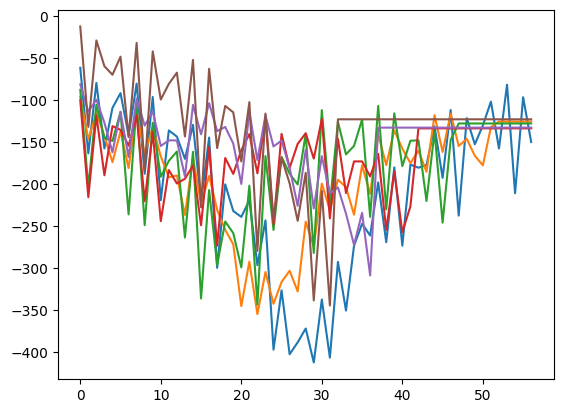

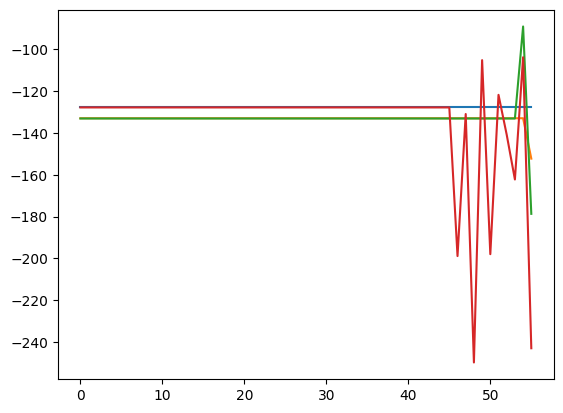

In [70]:
plt.plot(avg_by_sum_centered[::2, ::2][[0, 5, 10, 15, 20, 25]].T)
plt.show()
plt.plot(avg_by_sum_centered[::2, 1::2][[0, 1, 2, 10]].T)
plt.show()

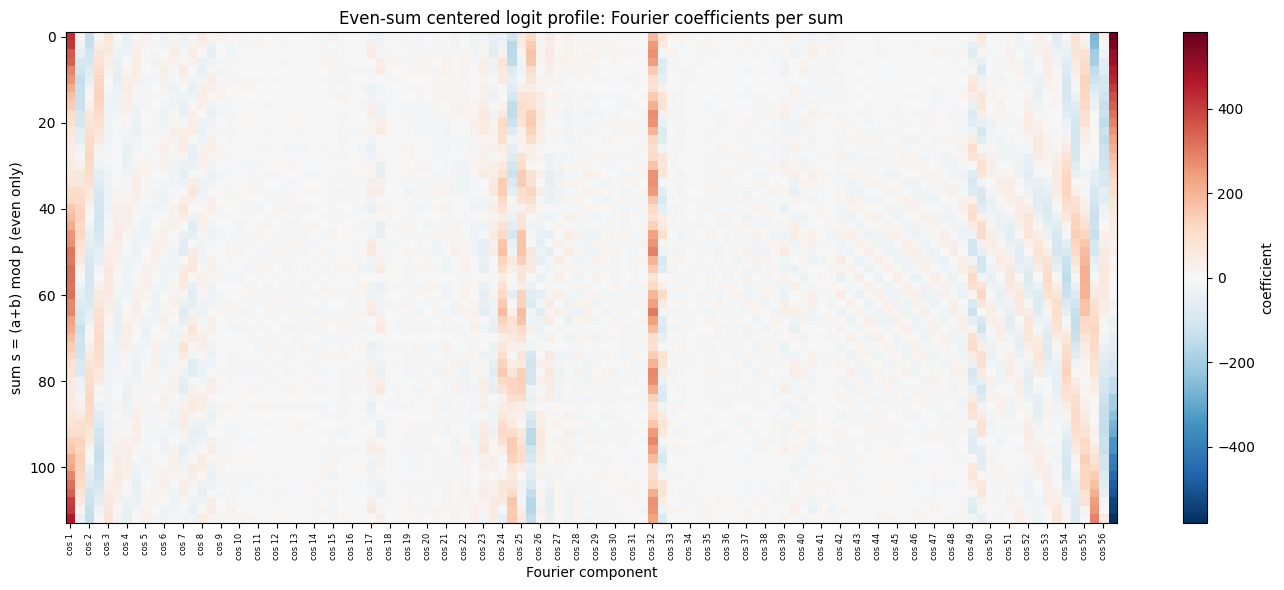

In [53]:
fig, ax = plt.subplots(figsize=(14, 6))
data = avg_by_sum_centered_ft.numpy()[::2, 1:]  # even sums, drop DC
im = ax.imshow(data, aspect='auto', cmap='RdBu_r',
               vmin=-np.abs(data).max(), vmax=np.abs(data).max())
ax.set_xlabel('Fourier component')
ax.set_ylabel('sum s = (a+b) mod p (even only)')
ax.set_xticks(range(0, data.shape[1], 2))
ax.set_xticklabels([freq_names[i+1] for i in range(0, data.shape[1], 2)], rotation=90, fontsize=6)
ax.set_yticks(range(0, data.shape[0], 10))
ax.set_yticklabels([str(2*i) for i in range(0, data.shape[0], 10)])
ax.set_title('Even-sum centered logit profile: Fourier coefficients per sum')
plt.colorbar(im, ax=ax, label='coefficient')
plt.tight_layout()
plt.show()

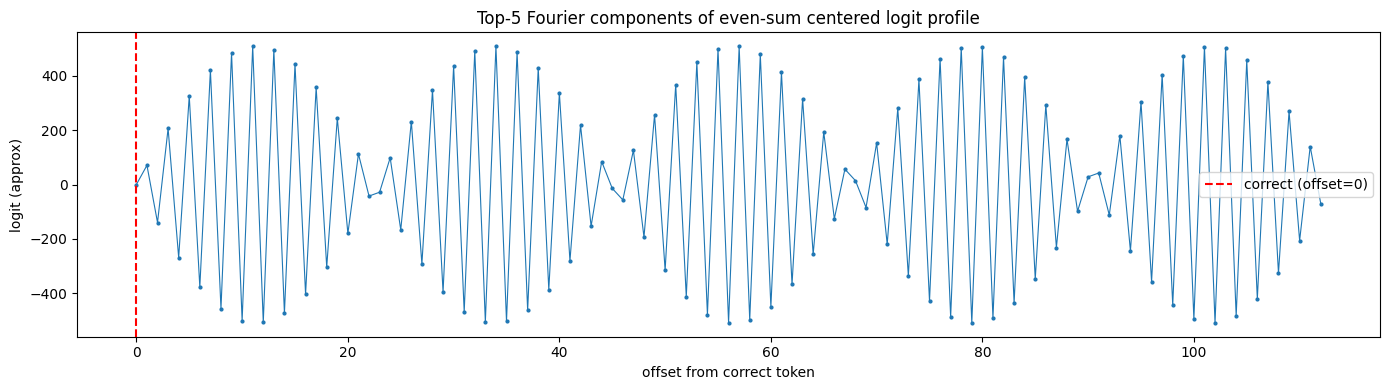

34


In [46]:
x = np.arange(p)
curve = (508.29 * np.sin(2*np.pi*54*x/p))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x, curve, 'o-', markersize=2, linewidth=0.8)
ax.axvline(0, color='red', linestyle='--', label='correct (offset=0)')
ax.set_xlabel('offset from correct token')
ax.set_ylabel('logit (approx)')
ax.set_title('Top-5 Fourier components of even-sum centered logit profile')
ax.legend()
plt.tight_layout()
plt.show()
print(curve.argmax())

In [ ]:
# Roll each row so that the correct answer (s) is at index 0
avg_by_sum_centered = torch.zeros_like(avg_by_sum)
for s in range(p):
    avg_by_sum_centered[s] = avg_by_sum[s].roll(-s)
# Now index 0 = correct token, index 1 = correct+1, etc.

avg_by_sum_centered_ft = fourier_transform_1d(avg_by_sum_centered.T, p=p)  # (vocab_shifted, p)

# But more useful: average across all sums to get a single "logit profile" centered on correct
profile = avg_by_sum_centered.mean(dim=0).numpy()  # (vocab,) — index 0 = correct token

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(profile, linewidth=0.8)
ax.axvline(0, color='red', linestyle='--', label='correct token')
ax.set_xlabel('offset from correct token')
ax.set_ylabel('mean logit')
ax.set_title('Average logit profile centered on correct answer')
ax.legend()
plt.tight_layout()
plt.show()

## Comparing Fourier basis

W_U_old shape: torch.Size([128, 113])
W_U_new shape: torch.Size([128, 113])


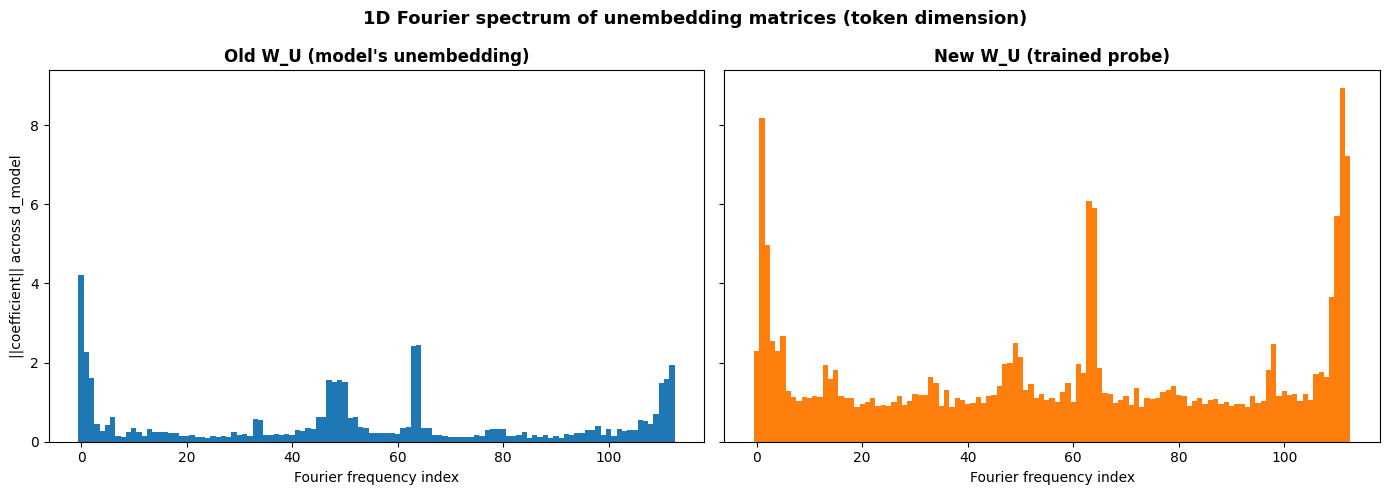

Saved: outputs/figs/fourier_wu_old_vs_new.png


In [5]:

from trainer.utils import fourier_transform_1d, get_fourier_basis
import matplotlib.pyplot as plt

fourier_basis = get_fourier_basis(p, "cpu")

# Old W_U: model's unembedding, shape [d_model, d_vocab] — take only number tokens [0..p-1]
W_U_old = model.W_U[:, :p].detach().cpu()  # [d_model, p]

# New W_U: probe weight, shape [p, d_model] — transpose to match
W_U_new = probe.weight.detach().cpu().T  # [d_model, p]

print(f"W_U_old shape: {W_U_old.shape}")
print(f"W_U_new shape: {W_U_new.shape}")

# fourier_transform_1d does arr @ fourier_basis.T, so arr's last dim must be p
# W_U is [d_model, p] — last dim is p, so apply directly: each row gets transformed
ft_old = fourier_transform_1d(W_U_old, fourier_basis=fourier_basis)  # [d_model, p]
ft_new = fourier_transform_1d(W_U_new, fourier_basis=fourier_basis)  # [d_model, p]

# Aggregate: norm across d_model for each frequency
freq_power_old = ft_old.norm(dim=0)  # [p]
freq_power_new = ft_new.norm(dim=0)  # [p]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].bar(range(p), freq_power_old.numpy(), width=1.0)
axes[0].set_title("Old W_U (model's unembedding)", fontweight="bold")
axes[0].set_xlabel("Fourier frequency index")
axes[0].set_ylabel("||coefficient|| across d_model")

axes[1].bar(range(p), freq_power_new.numpy(), width=1.0, color="tab:orange")
axes[1].set_title("New W_U (trained probe)", fontweight="bold")
axes[1].set_xlabel("Fourier frequency index")

fig.suptitle("1D Fourier spectrum of unembedding matrices (token dimension)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figs/fourier_wu_old_vs_new.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figs/fourier_wu_old_vs_new.png")


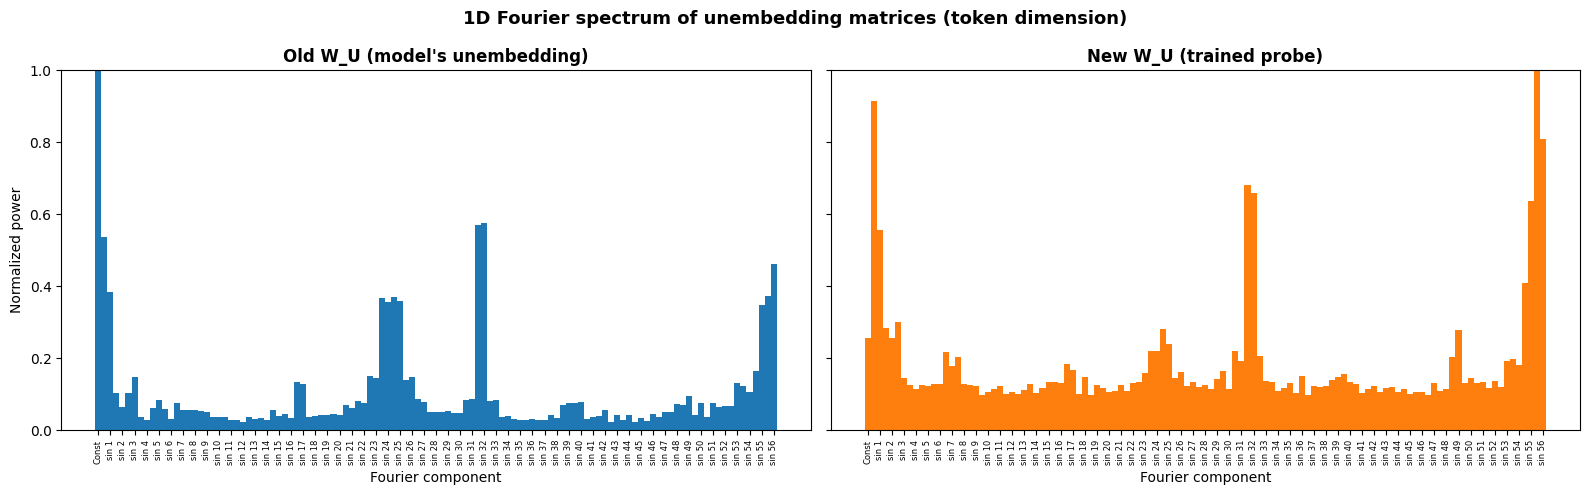

Saved: outputs/figs/fourier_wu_old_vs_new.png


In [6]:

from trainer.utils import get_fourier_basis_names

freq_names = get_fourier_basis_names(p)

# Normalize each to [0, 1]
freq_old_norm = freq_power_old / freq_power_old.max()
freq_new_norm = freq_power_new / freq_power_new.max()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].bar(range(p), freq_old_norm.numpy(), width=1.0)
axes[0].set_title("Old W_U (model's unembedding)", fontweight="bold")
axes[0].set_ylabel("Normalized power")

axes[1].bar(range(p), freq_new_norm.numpy(), width=1.0, color="tab:orange")
axes[1].set_title("New W_U (trained probe)", fontweight="bold")

for ax in axes:
    ax.set_xlabel("Fourier component")
    ax.set_ylim(0, 1)
    ax.set_xticks(range(0, p, 2))
    ax.set_xticklabels([freq_names[i] for i in range(0, p, 2)], rotation=90, fontsize=6)

fig.suptitle("1D Fourier spectrum of unembedding matrices (token dimension)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figs/fourier_wu_old_vs_new.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figs/fourier_wu_old_vs_new.png")


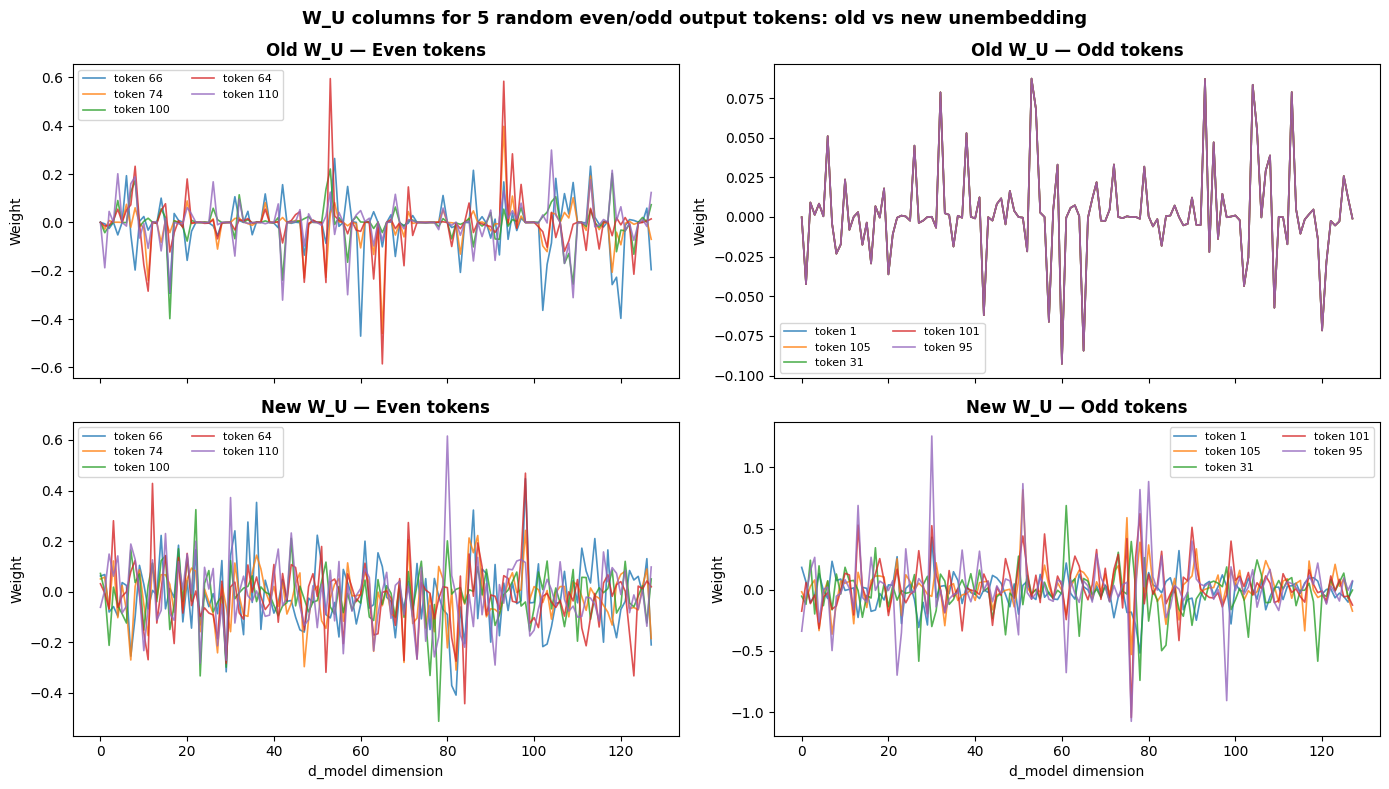

Even tokens: [64, 66, 74, 100, 110], Odd tokens: [1, 31, 95, 101, 105]
Saved: outputs/figs/wu_columns_old_vs_new.png


In [7]:

rng_plot = np.random.default_rng(7)

even_tokens = [t for t in range(p) if t % 2 == 0]
odd_tokens = [t for t in range(p) if t % 2 == 1]

pick_even = rng_plot.choice(even_tokens, 5, replace=False)
pick_odd = rng_plot.choice(odd_tokens, 5, replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for col, (tokens, parity_label) in enumerate([(pick_even, "Even tokens"), (pick_odd, "Odd tokens")]):
    for row, (W, wu_label) in enumerate([(W_U_old, "Old W_U"), (W_U_new, "New W_U")]):
        ax = axes[row, col]
        for t in tokens:
            ax.plot(W[:, t].numpy(), label=f"token {t}", alpha=0.8, linewidth=1.2)
        ax.set_title(f"{wu_label} — {parity_label}", fontweight="bold")
        ax.legend(fontsize=8, ncol=2)
        ax.set_ylabel("Weight")
        if row == 1:
            ax.set_xlabel("d_model dimension")

fig.suptitle("W_U columns for 5 random even/odd output tokens: old vs new unembedding",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figs/wu_columns_old_vs_new.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Even tokens: {sorted(pick_even)}, Odd tokens: {sorted(pick_odd)}")
print("Saved: outputs/figs/wu_columns_old_vs_new.png")


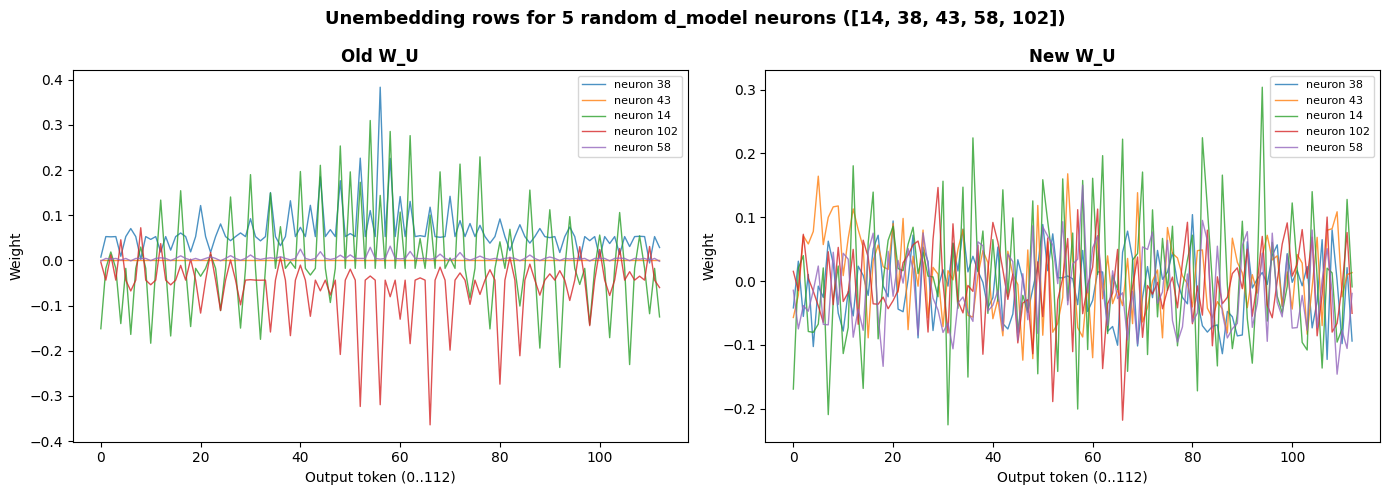

Saved: outputs/figs/wu_rows_old_vs_new.png


In [8]:

# Pick 5 random d_model neurons
neurons = rng_plot.choice(128, 5, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for col, (W, label, color) in enumerate([
    (W_U_old, "Old W_U", "tab:blue"),
    (W_U_new, "New W_U", "tab:orange"),
]):
    ax = axes[col]
    for n in neurons:
        ax.plot(W[n, :].numpy(), label=f"neuron {n}", alpha=0.8, linewidth=1.0)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Output token (0..112)")
    ax.set_ylabel("Weight")
    ax.legend(fontsize=8)

fig.suptitle(f"Unembedding rows for 5 random d_model neurons ({sorted(neurons)})",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figs/wu_rows_old_vs_new.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figs/wu_rows_old_vs_new.png")


In [9]:

import pandas as pd

freq_names = get_fourier_basis_names(p)

# Pick 4 of the 5 neurons we already plotted
neurons_4 = sorted(neurons[:4])

rows = []
for n in neurons_4:
    for wu_label, W in [("Old W_U", W_U_old), ("New W_U", W_U_new)]:
        ft = fourier_transform_1d(W[n, :], fourier_basis=fourier_basis)
        magnitudes = ft.abs()
        top5_idx = magnitudes.argsort(descending=True)[:5]
        for rank, idx in enumerate(top5_idx):
            rows.append({
                "Neuron": n,
                "W_U": wu_label,
                "Rank": rank + 1,
                "Component": freq_names[idx.item()],
                "Magnitude": magnitudes[idx].item(),
            })

df = pd.DataFrame(rows)
df_pivot = df.pivot_table(index=["Neuron", "W_U", "Rank"], values=["Component", "Magnitude"], aggfunc="first")
df_pivot = df_pivot[["Component", "Magnitude"]]

# Nicer display: one table per neuron
for n in neurons_4:
    sub = df[df["Neuron"] == n].copy()
    old = sub[sub["W_U"] == "Old W_U"][["Rank", "Component", "Magnitude"]].reset_index(drop=True)
    new = sub[sub["W_U"] == "New W_U"][["Rank", "Component", "Magnitude"]].reset_index(drop=True)
    old.columns = ["Rank", "Old Component", "Old Mag"]
    new.columns = ["Rank", "New Component", "New Mag"]
    merged = old.merge(new, on="Rank")
    merged["Old Mag"] = merged["Old Mag"].map(lambda x: f"{x:.4f}")
    merged["New Mag"] = merged["New Mag"].map(lambda x: f"{x:.4f}")
    print(f"\n=== Neuron {n} ===")
    display(merged.set_index("Rank"))



=== Neuron 14 ===


,Old Component,Old Mag,New Component,New Mag
Rank,,,,
1,cos 32,0.5796,sin 56,0.6461
2,cos 1,0.4666,cos 32,0.5746
3,sin 56,0.3953,sin 27,0.1905
4,sin 25,0.3769,cos 1,0.1820
5,sin 24,0.3523,sin 23,0.1424



=== Neuron 38 ===


,Old Component,Old Mag,New Component,New Mag
Rank,,,,
1,Const,0.6827,sin 5,0.1273
2,cos 1,0.2399,cos 36,0.1218
3,sin 56,0.2058,cos 6,0.1044
4,sin 55,0.1817,sin 32,0.1043
5,sin 32,0.1584,cos 54,0.0962



=== Neuron 43 ===


,Old Component,Old Mag,New Component,New Mag
Rank,,,,
1,Const,0.0007,cos 1,0.2070
2,sin 56,0.0003,sin 55,0.1912
3,sin 55,0.0003,sin 56,0.1752
4,cos 1,0.0001,cos 18,0.1452
5,sin 53,0.0001,sin 53,0.1356



=== Neuron 102 ===


,Old Component,Old Mag,New Component,New Mag
Rank,,,,
1,Const,0.6130,sin 32,0.2306
2,sin 32,0.3753,sin 56,0.1952
3,cos 24,0.2824,cos 49,0.1630
4,cos 25,0.2711,sin 31,0.1450
5,cos 1,0.2647,sin 55,0.1228


Logit grids: old=torch.Size([113, 113, 113]), new=torch.Size([113, 113, 113])


/tmp/ipykernel_51879/3073635563.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


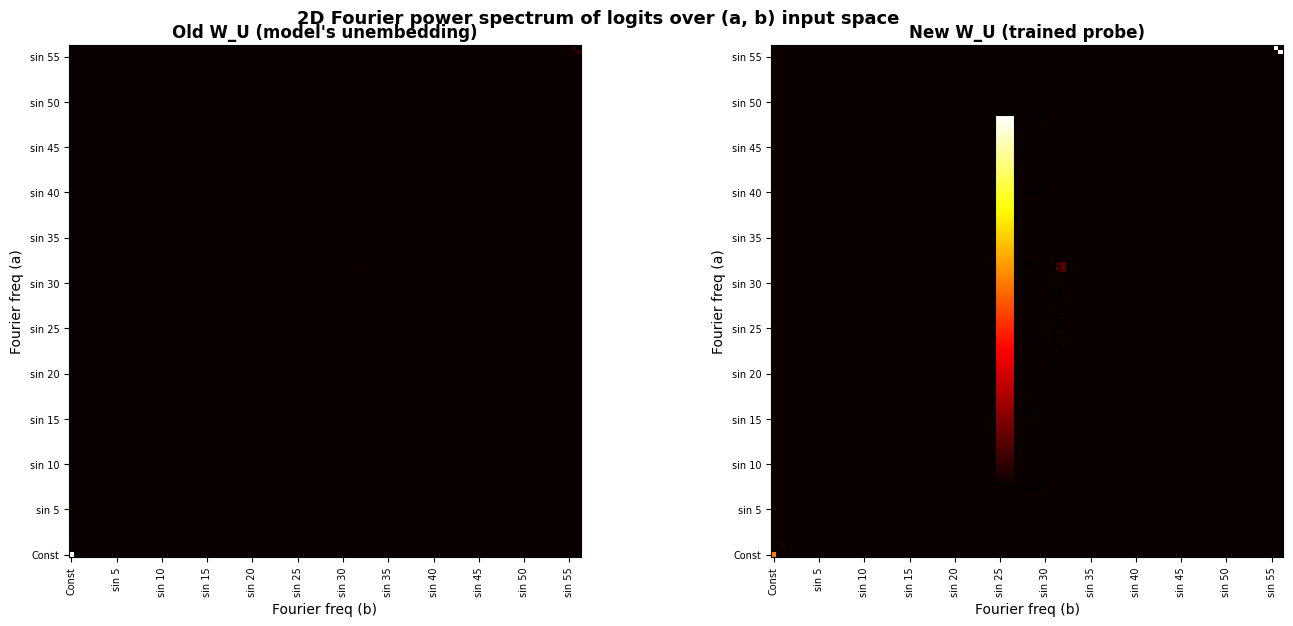

Saved: outputs/figs/fourier2d_logits_old_vs_new.png


In [10]:

from trainer.utils import fourier_transform_2d

# Get logits from new W_U (probe) applied to residual stream
# resid: [p^2, d_model], probe: d_model -> p
probe.eval()
with torch.no_grad():
    new_logits = probe(resid)  # [p^2, p]

# Reshape to [p, p, p] — logits[a, b, token]
new_logits_grid = new_logits.cpu().reshape(p, p, p)

# Also get old logits for comparison
old_logits = (resid.cpu() @ W_U_old).reshape(p, p, p)  # no bias in original W_U

print(f"Logit grids: old={old_logits.shape}, new={new_logits_grid.shape}")

# 2D Fourier transform over (a, b) for each output token, then take mean power
ft2d_old = fourier_transform_2d(old_logits.permute(2, 0, 1), fourier_basis=fourier_basis.cpu())  # [p, p, p]
ft2d_new = fourier_transform_2d(new_logits_grid.permute(2, 0, 1), fourier_basis=fourier_basis.cpu())

# Average squared magnitude across output tokens
power_old = (ft2d_old ** 2).mean(dim=0)  # [p, p]
power_new = (ft2d_new ** 2).mean(dim=0)  # [p, p]

# Normalize
power_old = power_old / power_old.max()
power_new = power_new / power_new.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, power, title in [
    (axes[0], power_old, "Old W_U (model's unembedding)"),
    (axes[1], power_new, "New W_U (trained probe)"),
]:
    im = ax.imshow(power.numpy(), cmap="hot", origin="lower", aspect="equal", vmin=0, vmax=1)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Fourier freq (b)")
    ax.set_ylabel("Fourier freq (a)")
    # Label a few ticks
    tick_pos = list(range(0, p, 10))
    tick_labels = [freq_names[i] for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=7)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(tick_labels, fontsize=7)

fig.colorbar(im, ax=axes, shrink=0.8, label="Normalized power")
fig.suptitle("2D Fourier power spectrum of logits over (a, b) input space", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figs/fourier2d_logits_old_vs_new.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/figs/fourier2d_logits_old_vs_new.png")


In [11]:

# Unnormalized power for old W_U
power_old_raw = (ft2d_old ** 2).mean(dim=0)  # [p, p]

# Flatten and get top 20
flat = power_old_raw.flatten()
top20_idx = flat.argsort(descending=True)[:20]

rows = []
for rank, idx in enumerate(top20_idx):
    i, j = idx.item() // p, idx.item() % p
    rows.append({
        "Rank": rank + 1,
        "Freq (a)": freq_names[i],
        "Freq (b)": freq_names[j],
        "Power": flat[idx].item(),
    })

df = pd.DataFrame(rows)
df["Power (norm)"] = df["Power"] / df["Power"].iloc[0]
display(df.set_index("Rank"))


,Freq (a),Freq (b),Power,Power (norm)
Rank,,,,
1,Const,Const,4.034995e+08,1.000000
2,sin 56,cos 56,2.189595e+07,0.054265
3,cos 56,sin 56,2.181848e+07,0.054073
4,sin 32,sin 32,2.577083e+06,0.006387
5,cos 32,sin 32,2.284631e+06,0.005662
6,sin 32,cos 32,2.282835e+06,0.005658
7,cos 32,cos 32,2.214992e+06,0.005489
8,sin 1,Const,1.733644e+06,0.004297
9,Const,sin 1,1.730394e+06,0.004288


In [12]:

# Use the raw (non-squared) 2D Fourier coefficients, averaged across output tokens
coeff_old = ft2d_old.mean(dim=0)  # [p, p] — mean coefficient across tokens

# Sort by power (squared) but display the coefficient
flat_power = power_old_raw.flatten()
flat_coeff = coeff_old.flatten()
top20_idx = flat_power.argsort(descending=True)[:20]

rows = []
for rank, idx in enumerate(top20_idx):
    i, j = idx.item() // p, idx.item() % p
    rows.append({
        "Rank": rank + 1,
        "Freq (a)": freq_names[i],
        "Freq (b)": freq_names[j],
        "Coefficient": flat_coeff[idx].item(),
        "Power": flat_power[idx].item(),
        "Power (norm)": flat_power[idx].item() / flat_power[top20_idx[0]].item(),
    })

df = pd.DataFrame(rows)
display(df.set_index("Rank"))


,Freq (a),Freq (b),Coefficient,Power,Power (norm)
Rank,,,,,
1,Const,Const,-18648.232422,4.034995e+08,1.000000
2,sin 56,cos 56,-1328.346924,2.189595e+07,0.054265
3,cos 56,sin 56,-1322.007568,2.181848e+07,0.054073
4,sin 32,sin 32,-460.547852,2.577083e+06,0.006387
5,cos 32,sin 32,-306.232300,2.284631e+06,0.005662
6,sin 32,cos 32,-305.679901,2.282835e+06,0.005658
7,cos 32,cos 32,-17.951008,2.214992e+06,0.005489
8,sin 1,Const,1203.217407,1.733644e+06,0.004297
9,Const,sin 1,1200.213623,1.730394e+06,0.004288


In [13]:

power_new_raw = (ft2d_new ** 2).mean(dim=0)
coeff_new = ft2d_new.mean(dim=0)

flat_power_new = power_new_raw.flatten()
flat_coeff_new = coeff_new.flatten()
top20_idx_new = flat_power_new.argsort(descending=True)[:20]

rows = []
for rank, idx in enumerate(top20_idx_new):
    i, j = idx.item() // p, idx.item() % p
    rows.append({
        "Rank": rank + 1,
        "Freq (a)": freq_names[i],
        "Freq (b)": freq_names[j],
        "Coefficient": flat_coeff_new[idx].item(),
        "Power": flat_power_new[idx].item(),
        "Power (norm)": flat_power_new[idx].item() / flat_power_new[top20_idx_new[0]].item(),
    })

df_new = pd.DataFrame(rows)
display(df_new.set_index("Rank"))


,Freq (a),Freq (b),Coefficient,Power,Power (norm)
Rank,,,,,
1,sin 56,cos 56,156.445389,2.660420e+07,1.000000
2,cos 56,sin 56,156.350174,2.654918e+07,0.997932
3,Const,Const,-206.254318,1.473911e+07,0.554014
4,sin 32,sin 32,-117.313286,2.875210e+06,0.108074
5,cos 32,sin 32,170.055313,2.769373e+06,0.104095
6,sin 32,cos 32,169.989227,2.767495e+06,0.104025
7,cos 32,cos 32,101.321213,2.749669e+06,0.103355
8,sin 56,sin 56,4.932081,8.171698e+05,0.030716
9,sin 1,sin 1,-21.199512,6.977638e+05,0.026228


In [14]:

# For each (a,b), extract the logit assigned to the correct token (a+b) % p
# This gives a single [p, p] grid per W_U

old_logits_flat = (resid.cpu() @ W_U_old)  # [p^2, p]
new_logits_flat = probe(resid).detach().cpu()  # [p^2, p]

# Gather the logit for the correct answer
correct_labels_cpu = correct_labels.cpu()
old_correct = old_logits_flat[torch.arange(p*p), correct_labels_cpu].reshape(p, p)
new_correct = new_logits_flat[torch.arange(p*p), correct_labels_cpu].reshape(p, p)

print(f"Old correct-token logits: {old_correct.shape}, mean={old_correct.mean():.2f}")
print(f"New correct-token logits: {new_correct.shape}, mean={new_correct.mean():.2f}")

# 2D Fourier transform
ft2d_old_correct = fourier_transform_2d(old_correct, fourier_basis=fourier_basis.cpu())
ft2d_new_correct = fourier_transform_2d(new_correct, fourier_basis=fourier_basis.cpu())

# Display top 20 by power for both
for label, ft in [("Old W_U", ft2d_old_correct), ("New W_U", ft2d_new_correct)]:
    flat = ft.flatten()
    power = flat ** 2
    top20 = power.argsort(descending=True)[:20]
    
    rows = []
    for rank, idx in enumerate(top20):
        i, j = idx.item() // p, idx.item() % p
        rows.append({
            "Rank": rank + 1,
            "Freq (a)": freq_names[i],
            "Freq (b)": freq_names[j],
            "Coefficient": flat[idx].item(),
            "Power": power[idx].item(),
            "Power (norm)": power[idx].item() / power[top20[0]].item(),
        })
    
    print(f"\n{'='*70}")
    print(f"  {label} — 2D Fourier of correct-token logits")
    print(f"{'='*70}")
    display(pd.DataFrame(rows).set_index("Rank"))


Old correct-token logits: torch.Size([113, 113]), mean=-99.62
New correct-token logits: torch.Size([113, 113]), mean=105.47

  Old W_U — 2D Fourier of correct-token logits


,Freq (a),Freq (b),Coefficient,Power,Power (norm)
Rank,,,,,
1,Const,Const,-11256.532227,1.267095e+08,1.000000
2,sin 56,cos 56,-2271.282959,5.158726e+06,0.040713
3,cos 56,sin 56,-2267.059570,5.139559e+06,0.040562
4,sin 1,Const,886.356262,7.856274e+05,0.006200
5,Const,sin 1,881.805359,7.775807e+05,0.006137
6,sin 1,sin 1,831.772522,6.918455e+05,0.005460
7,sin 2,sin 2,-751.760559,5.651439e+05,0.004460
8,cos 1,cos 1,-746.398376,5.571106e+05,0.004397
9,cos 2,cos 2,718.114807,5.156889e+05,0.004070



  New W_U — 2D Fourier of correct-token logits


,Freq (a),Freq (b),Coefficient,Power,Power (norm)
Rank,,,,,
1,Const,Const,11918.641602,1.420540e+08,1.000000
2,cos 1,cos 1,-1991.053833,3.964295e+06,0.027907
3,sin 1,sin 1,1476.959595,2.181410e+06,0.015356
4,cos 56,sin 56,-927.204712,8.597086e+05,0.006052
5,sin 56,cos 56,-925.143127,8.558898e+05,0.006025
6,sin 49,cos 49,-498.646484,2.486483e+05,0.001750
7,cos 49,sin 49,-498.538422,2.485406e+05,0.001750
8,sin 1,Const,-482.855530,2.331495e+05,0.001641
9,Const,sin 1,-480.118561,2.305138e+05,0.001623


In [15]:

# Product-to-sum trig identities:
# cos(k1*a) * cos(k2*b) = 1/2 [cos(k1*a - k2*b) + cos(k1*a + k2*b)]
# sin(k1*a) * sin(k2*b) = 1/2 [cos(k1*a - k2*b) - cos(k1*a + k2*b)]
# sin(k1*a) * cos(k2*b) = 1/2 [sin(k1*a + k2*b) + sin(k1*a - k2*b)]
# cos(k1*a) * sin(k2*b) = 1/2 [sin(k1*a + k2*b) - sin(k1*a - k2*b)]
#
# where angle = 2*pi*k/p

def product_to_sum(freq_a, freq_b):
    """Convert product form to sum form using trig identities.
    Returns list of (coeff, trig_fn, 'k1*a ± k2*b') strings."""
    # Parse "cos 56" -> ("cos", 56), "Const" -> ("const", 0), "sin 1" -> ("sin", 1)
    def parse(f):
        if f == "Const":
            return ("const", 0)
        parts = f.split()
        return (parts[0], int(parts[1]))
    
    fa, ka = parse(freq_a)
    fb, kb = parse(freq_b)
    
    # Handle Const cases
    if fa == "const" and fb == "const":
        return "DC bias (constant)"
    if fa == "const":
        return f"{fb}({kb}b)"
    if fb == "const":
        return f"{fa}({ka}a)"
    
    terms = []
    if fa == "cos" and fb == "cos":
        # 1/2 [cos(ka*a - kb*b) + cos(ka*a + kb*b)]
        terms.append(f"+1/2 cos({ka}a - {kb}b)")
        terms.append(f"+1/2 cos({ka}a + {kb}b)")
    elif fa == "sin" and fb == "sin":
        # 1/2 [cos(ka*a - kb*b) - cos(ka*a + kb*b)]
        terms.append(f"+1/2 cos({ka}a - {kb}b)")
        terms.append(f"-1/2 cos({ka}a + {kb}b)")
    elif fa == "sin" and fb == "cos":
        # 1/2 [sin(ka*a + kb*b) + sin(ka*a - kb*b)]
        terms.append(f"+1/2 sin({ka}a + {kb}b)")
        terms.append(f"+1/2 sin({ka}a - {kb}b)")
    elif fa == "cos" and fb == "sin":
        # 1/2 [sin(ka*a + kb*b) - sin(ka*a - kb*b)]
        terms.append(f"+1/2 sin({ka}a + {kb}b)")
        terms.append(f"-1/2 sin({ka}a - {kb}b)")
    
    return "  ".join(terms)


# Display for both W_Us (skip DC)
for label, ft in [("Old W_U", ft2d_old_correct), ("New W_U", ft2d_new_correct)]:
    flat = ft.flatten()
    power = flat ** 2
    top = power.argsort(descending=True)[:20]
    
    rows = []
    for idx in top:
        i, j = idx.item() // p, idx.item() % p
        fa, fb = freq_names[i], freq_names[j]
        if fa == "Const" and fb == "Const":
            continue
        c = flat[idx].item()
        rows.append({
            "Freq (a)": fa,
            "Freq (b)": fb,
            "Coeff": f"{c:.1f}",
            "Trig identity": product_to_sum(fa, fb),
        })
    
    print(f"\n{'='*80}")
    print(f"  {label} — non-DC components as trig functions of (a ± b)")
    print(f"  All arguments implicitly ×2π/p, p={p}")
    print(f"{'='*80}")
    display(pd.DataFrame(rows, index=range(1, len(rows)+1)))



  Old W_U — non-DC components as trig functions of (a ± b)
  All arguments implicitly ×2π/p, p=113


,Freq (a),Freq (b),Coeff,Trig identity
1,sin 56,cos 56,-2271.3,+1/2 sin(56a + 56b) +1/2 sin(56a - 56b)
2,cos 56,sin 56,-2267.1,+1/2 sin(56a + 56b) -1/2 sin(56a - 56b)
3,sin 1,Const,886.4,sin(1a)
4,Const,sin 1,881.8,sin(1b)
5,sin 1,sin 1,831.8,+1/2 cos(1a - 1b) -1/2 cos(1a + 1b)
6,sin 2,sin 2,-751.8,+1/2 cos(2a - 2b) -1/2 cos(2a + 2b)
7,cos 1,cos 1,-746.4,+1/2 cos(1a - 1b) +1/2 cos(1a + 1b)
8,cos 2,cos 2,718.1,+1/2 cos(2a - 2b) +1/2 cos(2a + 2b)
9,cos 54,sin 54,-630.9,+1/2 sin(54a + 54b) -1/2 sin(54a - 54b)
10,sin 54,cos 54,-630.9,+1/2 sin(54a + 54b) +1/2 sin(54a - 54b)



  New W_U — non-DC components as trig functions of (a ± b)
  All arguments implicitly ×2π/p, p=113


,Freq (a),Freq (b),Coeff,Trig identity
1,cos 1,cos 1,-1991.1,+1/2 cos(1a - 1b) +1/2 cos(1a + 1b)
2,sin 1,sin 1,1477.0,+1/2 cos(1a - 1b) -1/2 cos(1a + 1b)
3,cos 56,sin 56,-927.2,+1/2 sin(56a + 56b) -1/2 sin(56a - 56b)
4,sin 56,cos 56,-925.1,+1/2 sin(56a + 56b) +1/2 sin(56a - 56b)
5,sin 49,cos 49,-498.6,+1/2 sin(49a + 49b) +1/2 sin(49a - 49b)
6,cos 49,sin 49,-498.5,+1/2 sin(49a + 49b) -1/2 sin(49a - 49b)
7,sin 1,Const,-482.9,sin(1a)
8,Const,sin 1,-480.1,sin(1b)
9,cos 55,sin 55,341.5,+1/2 sin(55a + 55b) -1/2 sin(55a - 55b)
10,sin 55,cos 55,340.9,+1/2 sin(55a + 55b) +1/2 sin(55a - 55b)


In [16]:

def decompose_to_sum_basis(ft, p, freq_names):
    """Convert 2D Fourier coefficients to the sum/difference trig basis.
    
    Collects all contributions to each cos(k1*a ± k2*b) and sin(k1*a ± k2*b) term.
    """
    from collections import defaultdict
    accum = defaultdict(float)
    
    for i in range(p):
        for j in range(p):
            c = ft[i, j].item()
            if abs(c) < 1e-10:
                continue
            
            fa, fb = freq_names[i], freq_names[j]
            
            # Parse
            def parse(f):
                if f == "Const":
                    return ("const", 0)
                parts = f.split()
                return (parts[0], int(parts[1]))
            
            ta, ka = parse(fa)
            tb, kb = parse(fb)
            
            if ta == "const" and tb == "const":
                accum[("DC", 0, 0)] += c
            elif ta == "const":
                accum[(tb, 0, kb)] += c  # e.g. sin(kb*b) = sin(0*a + kb*b)
            elif tb == "const":
                accum[(ta, ka, 0)] += c  # e.g. cos(ka*a) = cos(ka*a + 0*b)
            else:
                # Product-to-sum
                if ta == "cos" and tb == "cos":
                    # c/2 * cos(ka*a - kb*b) + c/2 * cos(ka*a + kb*b)
                    accum[("cos", ka, -kb)] += c / 2
                    accum[("cos", ka, kb)] += c / 2
                elif ta == "sin" and tb == "sin":
                    # c/2 * cos(ka*a - kb*b) - c/2 * cos(ka*a + kb*b)
                    accum[("cos", ka, -kb)] += c / 2
                    accum[("cos", ka, kb)] -= c / 2
                elif ta == "sin" and tb == "cos":
                    # c/2 * sin(ka*a + kb*b) + c/2 * sin(ka*a - kb*b)
                    accum[("sin", ka, kb)] += c / 2
                    accum[("sin", ka, -kb)] += c / 2
                elif ta == "cos" and tb == "sin":
                    # c/2 * sin(ka*a + kb*b) - c/2 * sin(ka*a - kb*b)
                    accum[("sin", ka, kb)] += c / 2
                    accum[("sin", ka, -kb)] -= c / 2
    
    # Build table
    rows = []
    for (trig, k1, k2), coeff in accum.items():
        if trig == "DC":
            label = "DC"
        elif k2 == 0:
            label = f"{trig}({k1}a)"
        elif k1 == 0:
            label = f"{trig}({k2}b)"
        else:
            sign = "+" if k2 > 0 else "-"
            label = f"{trig}({k1}a {sign} {abs(k2)}b)"
        rows.append({"Component": label, "Coefficient": coeff, "|Coeff|": abs(coeff)})
    
    df = pd.DataFrame(rows).sort_values("|Coeff|", ascending=False).reset_index(drop=True)
    df.index = df.index + 1
    df.index.name = "Rank"
    return df


for label, ft in [("Old W_U", ft2d_old_correct), ("New W_U", ft2d_new_correct)]:
    df = decompose_to_sum_basis(ft, p, freq_names)
    # Skip DC, show top 20
    df = df[df["Component"] != "DC"].head(20)
    df["Coefficient"] = df["Coefficient"].map(lambda x: f"{x:.1f}")
    df["|Coeff|"] = df["|Coeff|"].map(lambda x: f"{x:.1f}")
    print(f"\n{'='*60}")
    print(f"  {label} — sum/difference basis (top 20, no DC)")
    print(f"  Arguments ×2π/{p}")
    print(f"{'='*60}")
    display(df)



  Old W_U — sum/difference basis (top 20, no DC)
  Arguments ×2π/113


,Component,Coefficient,|Coeff|
Rank,,,
2,sin(56a + 56b),-2269.2,2269.2
3,sin(1a),886.4,886.4
4,sin(1b),881.8,881.8
5,cos(1a + 1b),-789.1,789.1
6,cos(2a + 2b),734.9,734.9
7,sin(54a + 54b),-630.9,630.9
8,cos(56a - 56b),-541.2,541.2
9,sin(49a + 49b),-512.8,512.8
10,sin(32a + 32b),-373.9,373.9



  New W_U — sum/difference basis (top 20, no DC)
  Arguments ×2π/113


,Component,Coefficient,|Coeff|
Rank,,,
2,cos(1a + 1b),-1734.0,1734.0
3,sin(56a + 56b),-926.2,926.2
4,sin(49a + 49b),-498.6,498.6
5,sin(1a),-482.9,482.9
6,sin(1b),-480.1,480.1
7,sin(55a + 55b),341.2,341.2
8,cos(1a - 1b),-257.0,257.0
9,sin(55a - 56b),-201.5,201.5
10,sin(56a - 55b),201.1,201.1


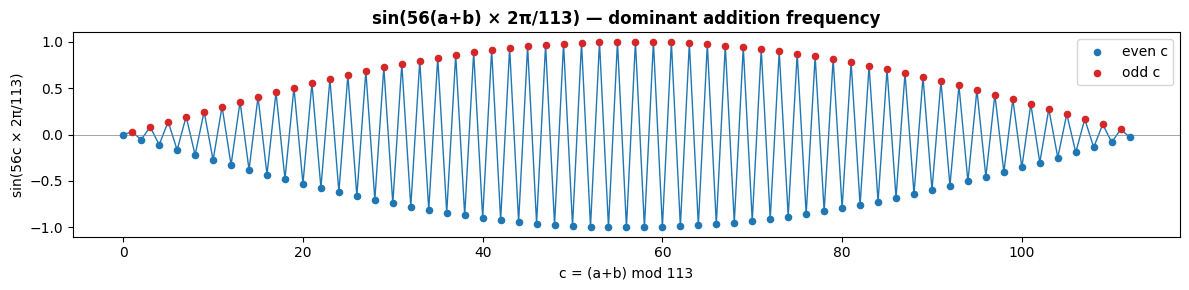

In [17]:

c = np.arange(p)
y = np.sin(2 * np.pi * 56 * c / p)

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(c, y, 'o-', markersize=3, linewidth=1)
ax.set_xlabel("c = (a+b) mod 113")
ax.set_ylabel("sin(56c × 2π/113)")
ax.set_title("sin(56(a+b) × 2π/113) — dominant addition frequency", fontweight="bold")
ax.axhline(0, color='gray', linewidth=0.5)

# Highlight even vs odd
even_c = c[c % 2 == 0]
odd_c = c[c % 2 == 1]
ax.scatter(even_c, np.sin(2*np.pi*56*even_c/p), c='tab:blue', s=20, zorder=5, label='even c')
ax.scatter(odd_c, np.sin(2*np.pi*56*odd_c/p), c='tab:red', s=20, zorder=5, label='odd c')
ax.legend()
plt.tight_layout()
plt.show()


In [18]:

from analysis.analyzer import ModelAnalyzer

a = ModelAnalyzer(model, task="ptg", device="cuda", label="PT-G (wd=0.5)")
a.summary()


Moving model to device:  cuda
Moving model to device:  cuda
ModelAnalyzer: PT-G (wd=0.5)
  Architecture: 1L4H, d_model=128, d_mlp=512
  p=113, vocab=117, n_ctx=6
  Device: cuda
  Parameters: 228,597


'ModelAnalyzer: PT-G (wd=0.5)\n  Architecture: 1L4H, d_model=128, d_mlp=512\n  p=113, vocab=117, n_ctx=6\n  Device: cuda\n  Parameters: 228,597'

In [19]:

# Get 2D Fourier decomposition of logits from the analyzer
fl = a.fourier_logits()

# fl["fourier_coeffs"] is (vocab, p, p) — take only number tokens [0..p-1]
ft_coeffs = fl["fourier_coeffs"][:p]  # (p, p, p)
freq_names = fl["fourier_names"]

# For the correct-token analysis: extract coeff for token c = (a+b)%p at each (a,b)
# But fourier_logits gives the 2D FT for each output token separately
# We can also just look at the mean power across number tokens
power_avg = fl["power_per_output"][:p].mean(dim=0)  # (p, p)

# Use decompose_to_sum_basis on the average coefficients across number tokens
coeff_avg = ft_coeffs.mean(dim=0)  # (p, p)

df_model = decompose_to_sum_basis(coeff_avg, p, freq_names)
df_model = df_model[df_model["Component"] != "DC"].head(20)
df_model["Coefficient"] = df_model["Coefficient"].map(lambda x: f"{x:.1f}")
df_model["|Coeff|"] = df_model["|Coeff|"].map(lambda x: f"{x:.1f}")

print("PT-G model logits — 2D Fourier in sum/difference basis (top 20, no DC)")
print("(averaged across all number output tokens)")
display(df_model)


PT-G model logits — 2D Fourier in sum/difference basis (top 20, no DC)
(averaged across all number output tokens)


,Component,Coefficient,|Coeff|
Rank,,,
2,sin(56a + 56b),-1325.2,1325.2
3,sin(1a),1203.2,1203.2
4,sin(1b),1200.2,1200.2
5,cos(56a - 56b),-738.1,738.1
6,cos(1a + 1b),-432.1,432.1
7,sin(32a + 32b),-306.0,306.0
8,cos(55b),300.6,300.6
9,cos(55a),300.3,300.3
10,sin(55a),272.7,272.7


In [20]:

# Pick a few odd examples: (a+b) % 113 is odd
odd_mask = a.result_labels % 2 == 1
odd_indices = np.where(odd_mask)[0]

# Take 5 random odd examples
rng_ex = np.random.default_rng(0)
samples = rng_ex.choice(odd_indices, 5, replace=False)

logits_pos3 = a.logits[:, 3].cpu()  # [p^2, vocab]
tokenizer = a.tokenizer

rows = []
for idx in samples:
    ab_a = idx // p
    ab_b = idx % p
    correct = (ab_a + ab_b) % p
    top5_vals, top5_ids = logits_pos3[idx].topk(5)
    
    for rank, (tid, val) in enumerate(zip(top5_ids, top5_vals)):
        tid = tid.item()
        token_str = tokenizer.decode([tid], skip_special_tokens=False, stop_at_eos=False)
        rows.append({
            "Example": f"{ab_a}+{ab_b}={correct} (odd)",
            "Rank": rank + 1,
            "Token": token_str,
            "Token ID": tid,
            "Logit": f"{val.item():.2f}",
        })

df = pd.DataFrame(rows)
for ex, grp in df.groupby("Example", sort=False):
    print(f"\n{ex}")
    display(grp[["Rank", "Token", "Token ID", "Logit"]].set_index("Rank"))



71+105=63 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,151.16
2,112,112,31.68
3,0,0,30.65
4,2,2,-9.00
5,10,10,-21.43



57+83=27 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,109.70
2,112,112,31.84
3,2,2,16.63
4,108,108,9.32
5,6,6,-12.54



30+53=83 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,61.34
2,2,2,6.22
3,104,104,-15.87
4,108,108,-16.75
5,112,112,-24.14



34+88=9 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,-24.17
2,108,108,-49.97
3,2,2,-54.72
4,112,112,-57.03
5,104,104,-64.64



96+7=103 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,-23.04
2,4,4,-50.63
3,110,110,-54.65
4,0,0,-58.23
5,8,8,-64.33


In [21]:

logits_centered = logits_pos3 - logits_pos3.mean(dim=-1, keepdim=True)

rows = []
for idx in samples:
    ab_a = idx // p
    ab_b = idx % p
    correct = (ab_a + ab_b) % p
    top5_vals, top5_ids = logits_centered[idx].topk(5)
    
    # Also show where the correct answer ranks
    correct_logit = logits_centered[idx, correct].item()
    correct_rank = (logits_centered[idx] > correct_logit).sum().item() + 1
    
    for rank, (tid, val) in enumerate(zip(top5_ids, top5_vals)):
        tid = tid.item()
        token_str = tokenizer.decode([tid], skip_special_tokens=False, stop_at_eos=False)
        rows.append({
            "Example": f"{ab_a}+{ab_b}={correct} (odd)",
            "Rank": rank + 1,
            "Token": token_str,
            "Token ID": tid,
            "Logit": f"{val.item():.2f}",
        })
    rows.append({
        "Example": f"{ab_a}+{ab_b}={correct} (odd)",
        "Rank": f"...{correct_rank}",
        "Token": f"{correct} (correct)",
        "Token ID": correct,
        "Logit": f"{correct_logit:.2f}",
    })

df = pd.DataFrame(rows)
for ex, grp in df.groupby("Example", sort=False):
    print(f"\n{ex}")
    display(grp[["Rank", "Token", "Token ID", "Logit"]].set_index("Rank"))



71+105=63 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,349.24
2,112,112,229.76
3,0,0,228.73
4,2,2,189.08
5,10,10,176.65
...19,63 (correct),63,61.17



57+83=27 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,310.12
2,112,112,232.26
3,2,2,217.05
4,108,108,209.74
5,6,6,187.89
...21,27 (correct),27,58.08



30+53=83 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,209.12
2,2,2,154.01
3,104,104,131.91
4,108,108,131.03
5,112,112,123.64
...19,83 (correct),83,40.05



34+88=9 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,169.20
2,108,108,143.40
3,2,2,138.65
4,112,112,136.35
5,104,104,128.74
...19,9 (correct),9,47.56



96+7=103 (odd)


,Token,Token ID,Logit
Rank,,,
1,<eos>,115,169.07
2,4,4,141.48
3,110,110,137.46
4,0,0,133.88
5,8,8,127.78
...18,103 (correct),103,46.82


In [22]:

# Centered logits: [p^2, vocab] -> reshape to [vocab, p, p] for 2D FT
logits_centered_vpp = logits_centered.reshape(p, p, -1).permute(2, 0, 1)  # [vocab, p, p]

fb_cpu = get_fourier_basis(p, "cpu")
ft_centered = fourier_transform_2d(logits_centered_vpp, fourier_basis=fb_cpu)  # [vocab, p, p]

# Average coefficients across number tokens only [0..p-1]
coeff_avg_centered = ft_centered[:p].mean(dim=0)  # [p, p]

df_centered = decompose_to_sum_basis(coeff_avg_centered, p, freq_names)
df_centered = df_centered[df_centered["Component"] != "DC"].head(20)
df_centered["Coefficient"] = df_centered["Coefficient"].map(lambda x: f"{x:.1f}")
df_centered["|Coeff|"] = df_centered["|Coeff|"].map(lambda x: f"{x:.1f}")

print("PT-G centered logits — 2D Fourier in sum/difference basis (top 20, no DC)")
display(df_centered)


PT-G centered logits — 2D Fourier in sum/difference basis (top 20, no DC)


,Component,Coefficient,|Coeff|
Rank,,,
2,sin(56a + 56b),-153.9,153.9
3,cos(1a + 1b),-22.1,22.1
4,cos(56a - 56b),-15.4,15.4
5,sin(1b),13.1,13.1
6,sin(1a),12.9,12.9
7,sin(55a + 55b),6.9,6.9
8,cos(1a - 1b),5.8,5.8
9,cos(55b),5.6,5.6
10,cos(55a),5.6,5.6


In [23]:

df_centered = decompose_to_sum_basis(coeff_avg_centered, p, freq_names)
df_centered = df_centered[df_centered["Component"] != "DC"].head(20).reset_index(drop=True)
df_centered.index = df_centered.index + 1
df_centered.index.name = "Rank"
df_centered["Coefficient"] = df_centered["Coefficient"].map(lambda x: f"{x:.1f}")
df_centered["|Coeff|"] = df_centered["|Coeff|"].map(lambda x: f"{x:.1f}")

print("PT-G centered logits — 2D Fourier in sum/difference basis (top 20, no DC)")
display(df_centered)


PT-G centered logits — 2D Fourier in sum/difference basis (top 20, no DC)


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),-153.9,153.9
2,cos(1a + 1b),-22.1,22.1
3,cos(56a - 56b),-15.4,15.4
4,sin(1b),13.1,13.1
5,sin(1a),12.9,12.9
6,sin(55a + 55b),6.9,6.9
7,cos(1a - 1b),5.8,5.8
8,cos(55b),5.6,5.6
9,cos(55a),5.6,5.6


In [24]:

def decompose_to_sum_basis_v2(ft, p, freq_names):
    """Convert 2D Fourier coefficients to sum/difference trig basis,
    properly accounting for orthonormal basis normalization.
    
    Basis norms: Const = 1/√p, cos_k/sin_k = √(2/p)
    Product contributions to f(a,b):
      trig × trig:    c * (2/p) * trig(k1 a) * trig(k2 b)  -> c/p per sum/diff term
      Const × trig:   c * √(2)/p * trig(k b)
      Const × Const:  c / p
    """
    from collections import defaultdict
    accum = defaultdict(float)
    sqrt2 = np.sqrt(2)
    
    for i in range(p):
        for j in range(p):
            c = ft[i, j].item()
            if abs(c) < 1e-10:
                continue
            
            def parse(f):
                if f == "Const":
                    return ("const", 0)
                parts = f.split()
                return (parts[0], int(parts[1]))
            
            ta, ka = parse(freq_names[i])
            tb, kb = parse(freq_names[j])
            
            if ta == "const" and tb == "const":
                accum[("DC", 0, 0)] += c / p
            elif ta == "const":
                accum[(tb, 0, kb)] += c * sqrt2 / p
            elif tb == "const":
                accum[(ta, ka, 0)] += c * sqrt2 / p
            else:
                # trig × trig: each sum/diff term gets c/p
                if ta == "cos" and tb == "cos":
                    accum[("cos", ka, -kb)] += c / p
                    accum[("cos", ka, kb)] += c / p
                elif ta == "sin" and tb == "sin":
                    accum[("cos", ka, -kb)] += c / p
                    accum[("cos", ka, kb)] -= c / p
                elif ta == "sin" and tb == "cos":
                    accum[("sin", ka, kb)] += c / p
                    accum[("sin", ka, -kb)] += c / p
                elif ta == "cos" and tb == "sin":
                    accum[("sin", ka, kb)] += c / p
                    accum[("sin", ka, -kb)] -= c / p
    
    rows = []
    for (trig, k1, k2), coeff in accum.items():
        if trig == "DC":
            label = "DC"
        elif k2 == 0:
            label = f"{trig}({k1}a)"
        elif k1 == 0:
            label = f"{trig}({k2}b)"
        else:
            sign = "+" if k2 > 0 else "-"
            label = f"{trig}({k1}a {sign} {abs(k2)}b)"
        rows.append({"Component": label, "Coefficient": coeff, "|Coeff|": abs(coeff)})
    
    df = pd.DataFrame(rows).sort_values("|Coeff|", ascending=False).reset_index(drop=True)
    df.index = df.index + 1
    df.index.name = "Rank"
    return df


# Redo the centered logits analysis
df_fixed = decompose_to_sum_basis_v2(coeff_avg_centered, p, freq_names)
df_fixed = df_fixed[df_fixed["Component"] != "DC"].head(20)
df_fixed["Coefficient"] = df_fixed["Coefficient"].map(lambda x: f"{x:.2f}")
df_fixed["|Coeff|"] = df_fixed["|Coeff|"].map(lambda x: f"{x:.2f}")

print("PT-G centered logits — corrected normalization (top 20, no DC)")
display(df_fixed)


PT-G centered logits — corrected normalization (top 20, no DC)


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),-2.72,2.72
3,cos(1a + 1b),-0.39,0.39
4,cos(56a - 56b),-0.27,0.27
5,sin(1b),0.16,0.16
6,sin(1a),0.16,0.16
7,sin(55a + 55b),0.12,0.12
8,cos(1a - 1b),0.10,0.10
9,cos(56a + 55b),0.10,0.10
10,cos(55a + 56b),0.10,0.10


In [25]:

# The key: the logit for token t at input (a,b) is:
#   logit(a, b, t) = resid(a,b) @ W_U[:, t]
#
# We've been looking at the AVERAGE across tokens. But the mechanism lives
# in individual token logits. Let's look at a few specific tokens.

# Get the 2D Fourier coefficients per output token (not averaged)
# ft_centered: [vocab, p, p]
ft_per_token = fourier_transform_2d(logits_centered_vpp[:p], fourier_basis=fb_cpu)  # [p, p, p]

# For a specific even token, e.g. t=10, and an odd token, e.g. t=11
# Show the top Fourier components
for t in [10, 11, tokenizer.eos_token_id]:
    if t < p:
        ft_t = ft_per_token[t]  # [p, p]
        label = f"token {t} ({'even' if t%2==0 else 'odd'})"
    else:
        # EOS token
        ft_t = fourier_transform_2d(
            logits_centered_vpp[t:t+1], fourier_basis=fb_cpu
        )[0]
        label = f"token <eos> ({t})"
    
    df_t = decompose_to_sum_basis_v2(ft_t, p, freq_names)
    df_t = df_t.head(5)
    df_t["Coefficient"] = df_t["Coefficient"].map(lambda x: f"{x:.2f}")
    df_t["|Coeff|"] = df_t["|Coeff|"].map(lambda x: f"{x:.2f}")
    print(f"\n{label}")
    display(df_t)



token 10 (even)


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),89.36,89.36
2,DC,49.86,49.86
3,sin(32a + 32b),-19.94,19.94
4,cos(1a + 1b),13.32,13.32
5,cos(56a - 56b),9.27,9.27



token 11 (odd)


,Component,Coefficient,|Coeff|
Rank,,,
1,DC,35.93,35.93
2,sin(56a + 56b),19.21,19.21
3,cos(56a - 56b),3.74,3.74
4,cos(1a + 1b),3.51,3.51
5,sin(1b),-3.45,3.45



token <eos> (115)


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),250.26,250.26
2,DC,69.49,69.49
3,cos(1a + 1b),33.71,33.71
4,cos(56a - 56b),19.64,19.64
5,sin(55a + 55b),-10.31,10.31


In [26]:

# The key insight: sin(56(a+b)) appears in EVERY token's logit, but with 
# a token-dependent coefficient. Let's extract that coefficient for all tokens.

sin56_coeffs = []
cos56_coeffs = []
dc_coeffs = []

for t in range(p):
    df_t = decompose_to_sum_basis_v2(ft_per_token[t], p, freq_names)
    sin56_row = df_t[df_t["Component"] == "sin(56a + 56b)"]
    cos56_row = df_t[df_t["Component"] == "cos(56a + 56b)"]
    dc_row = df_t[df_t["Component"] == "DC"]
    
    sin56_coeffs.append(sin56_row["Coefficient"].values[0] if len(sin56_row) > 0 else 0)
    cos56_coeffs.append(cos56_row["Coefficient"].values[0] if len(cos56_row) > 0 else 0)
    dc_coeffs.append(dc_row["Coefficient"].values[0] if len(dc_row) > 0 else 0)

sin56_coeffs = np.array(sin56_coeffs)
cos56_coeffs = np.array(cos56_coeffs)
dc_coeffs = np.array(dc_coeffs)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].bar(range(p), dc_coeffs, width=1, color=['tab:blue' if t%2==0 else 'tab:red' for t in range(p)])
axes[0].set_ylabel("DC coeff")
axes[0].set_title("DC bias per output token", fontweight="bold")

axes[1].bar(range(p), sin56_coeffs, width=1, color=['tab:blue' if t%2==0 else 'tab:red' for t in range(p)])
axes[1].set_ylabel("sin(56(a+b)) coeff")
axes[1].set_title("Coefficient of sin(56(a+b)) per output token", fontweight="bold")

# Overlay the expected pattern: A * sin(56 * t * 2pi/p)
t_arr = np.arange(p)
expected = np.sin(2 * np.pi * 56 * t_arr / p)
# Scale to match
scale = sin56_coeffs[sin56_coeffs > 10].mean() / expected[t_arr % 2 == 0].mean() if expected[t_arr % 2 == 0].mean() != 0 else 1
axes[1].plot(t_arr, expected * np.max(np.abs(sin56_coeffs)) * 0.8, 'k--', alpha=0.5, label=f'~sin(56t·2π/{p})')
axes[1].legend()

axes[2].bar(range(p), cos56_coeffs, width=1, color=['tab:blue' if t%2==0 else 'tab:red' for t in range(p)])
axes[2].set_ylabel("cos(56(a+b)) coeff")
axes[2].set_title("Coefficient of cos(56(a+b)) per output token", fontweight="bold")
axes[2].set_xlabel("Output token t")

for ax in axes:
    handles = [
        plt.Line2D([0],[0], color='tab:blue', lw=6, label='even t'),
        plt.Line2D([0],[0], color='tab:red', lw=6, label='odd t'),
    ]
    ax.legend(handles=handles, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig("outputs/figs/fourier_coeff_per_token.png", dpi=150, bbox_inches="tight")
plt.show()


In [27]:

plt.show()


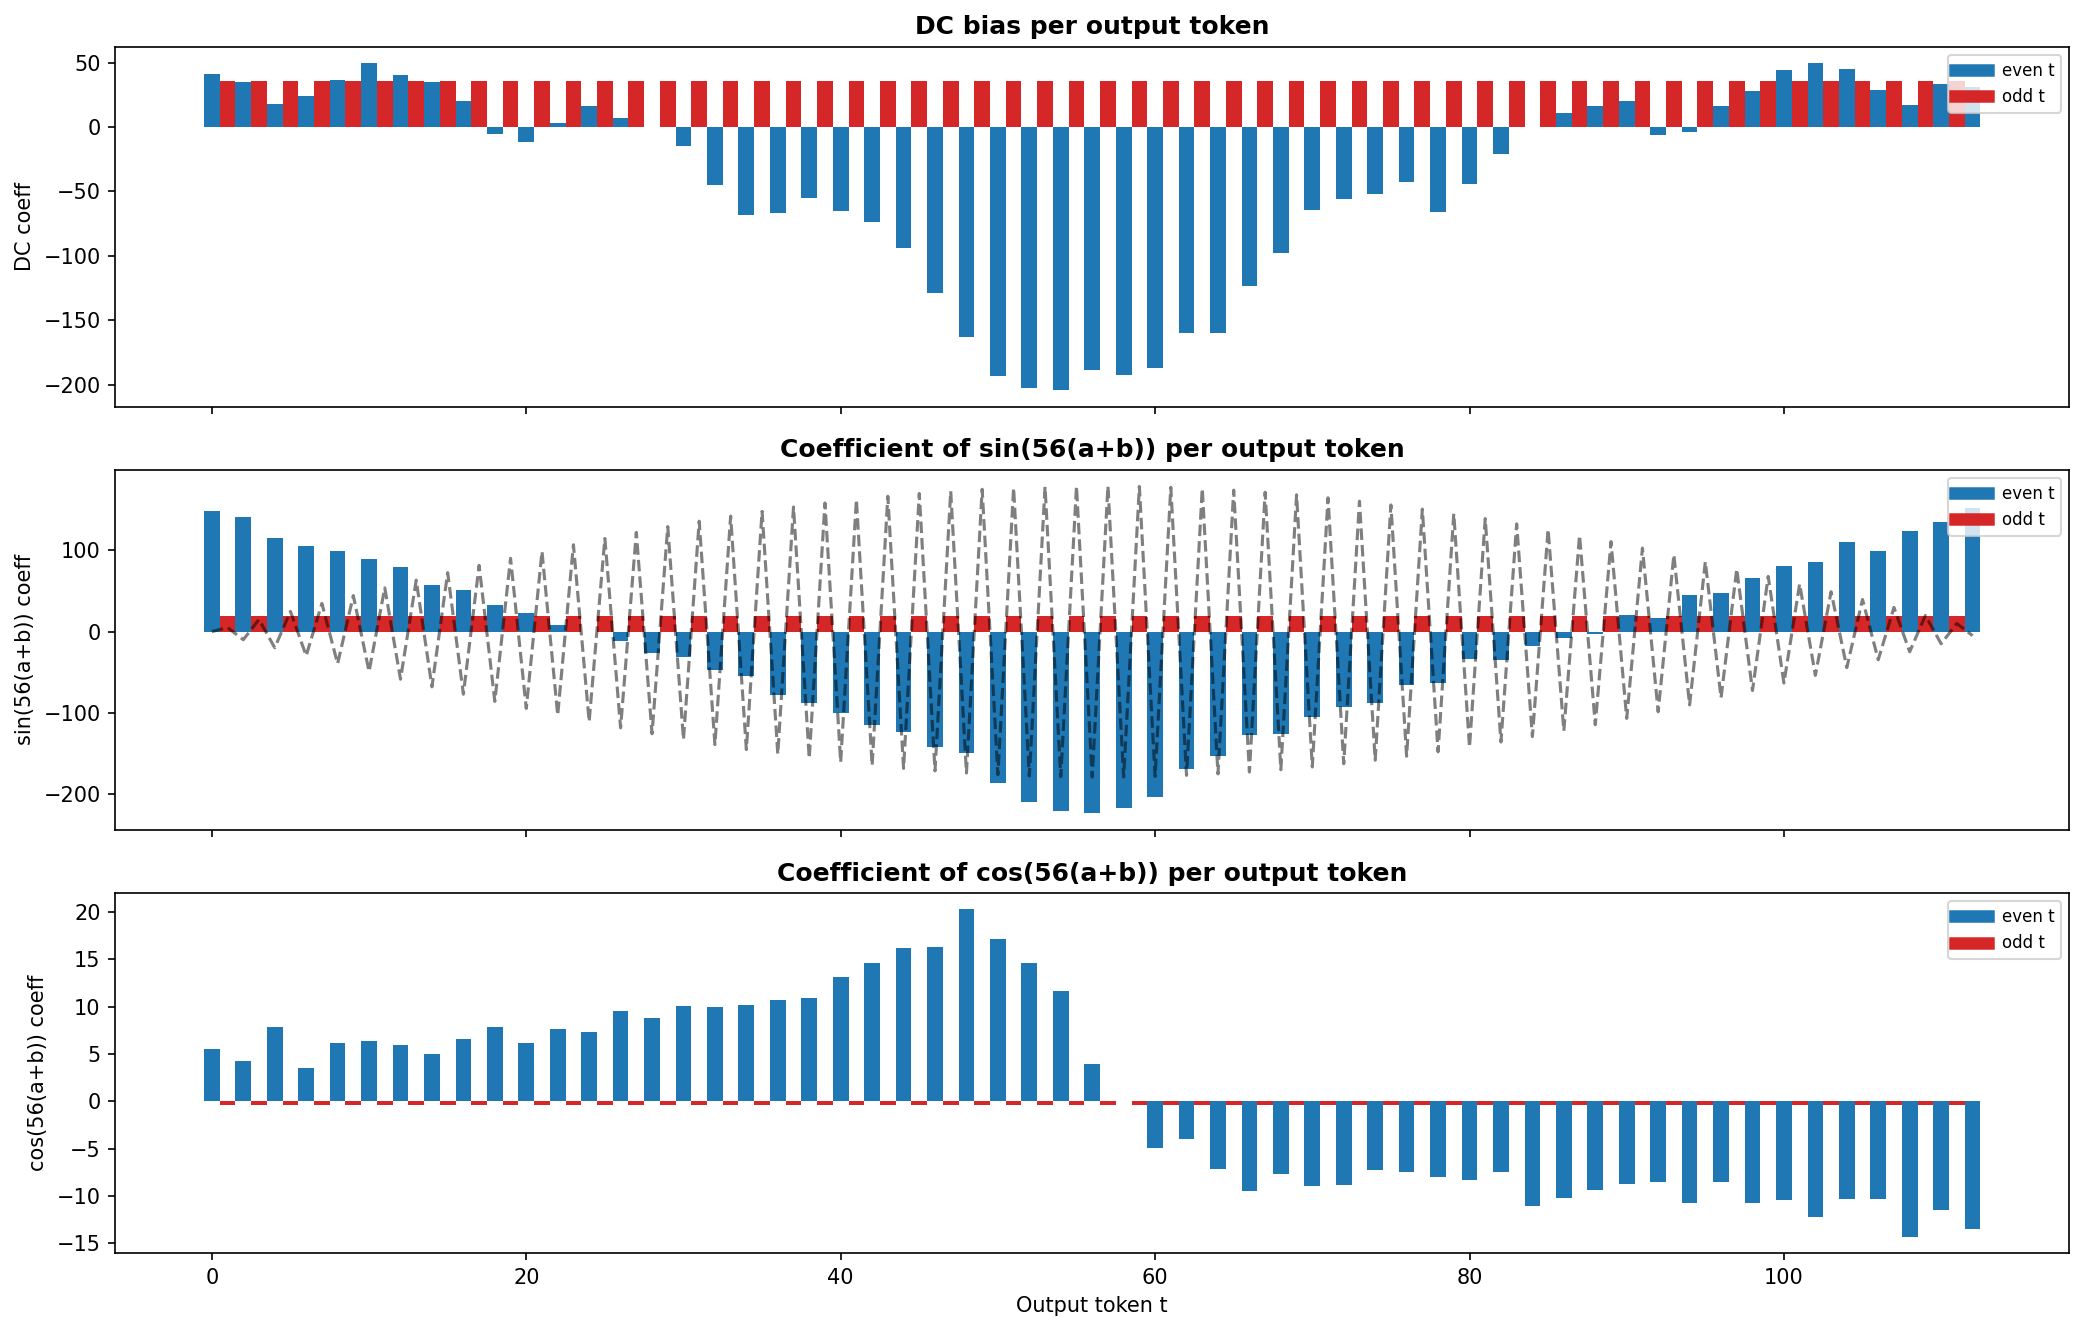

In [28]:

# Display inline
from IPython.display import display as ipy_display
from IPython.display import Image as IPImage
ipy_display(IPImage(filename="outputs/figs/fourier_coeff_per_token.png"))


In [29]:

even_dc = dc_coeffs[::2]
odd_dc = dc_coeffs[1::2]
print(f"DC bias — even tokens: mean={even_dc.mean():.2f}, odd tokens: mean={odd_dc.mean():.2f}")
print(f"Difference (odd - even): {odd_dc.mean() - even_dc.mean():.2f}")

even_sin56 = np.abs(sin56_coeffs[::2])
odd_sin56 = np.abs(sin56_coeffs[1::2])
print(f"\n|sin(56(a+b))| coeff — even tokens: mean={even_sin56.mean():.2f}, odd tokens: mean={odd_sin56.mean():.2f}")
print(f"Ratio even/odd: {even_sin56.mean() / odd_sin56.mean():.1f}x")

# Also get the EOS token's decomposition
ft_eos = fourier_transform_2d(
    logits_centered_vpp[tokenizer.eos_token_id:tokenizer.eos_token_id+1], fourier_basis=fb_cpu
)[0]
df_eos = decompose_to_sum_basis_v2(ft_eos, p, freq_names)
print(f"\nEOS token — top components:")
df_eos_top = df_eos.head(8).copy()
df_eos_top["Coefficient"] = df_eos_top["Coefficient"].map(lambda x: f"{x:.2f}")
df_eos_top["|Coeff|"] = df_eos_top["|Coeff|"].map(lambda x: f"{x:.2f}")
display(df_eos_top)


DC bias — even tokens: mean=-38.41, odd tokens: mean=35.93
Difference (odd - even): 74.33

|sin(56(a+b))| coeff — even tokens: mean=92.16, odd tokens: mean=19.21
Ratio even/odd: 4.8x

EOS token — top components:


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),250.26,250.26
2,DC,69.49,69.49
3,cos(1a + 1b),33.71,33.71
4,cos(56a - 56b),19.64,19.64
5,sin(55a + 55b),-10.31,10.31
6,cos(56a + 55b),-9.37,9.37
7,cos(55a + 56b),-9.36,9.36
8,cos(1a - 1b),-9.21,9.21


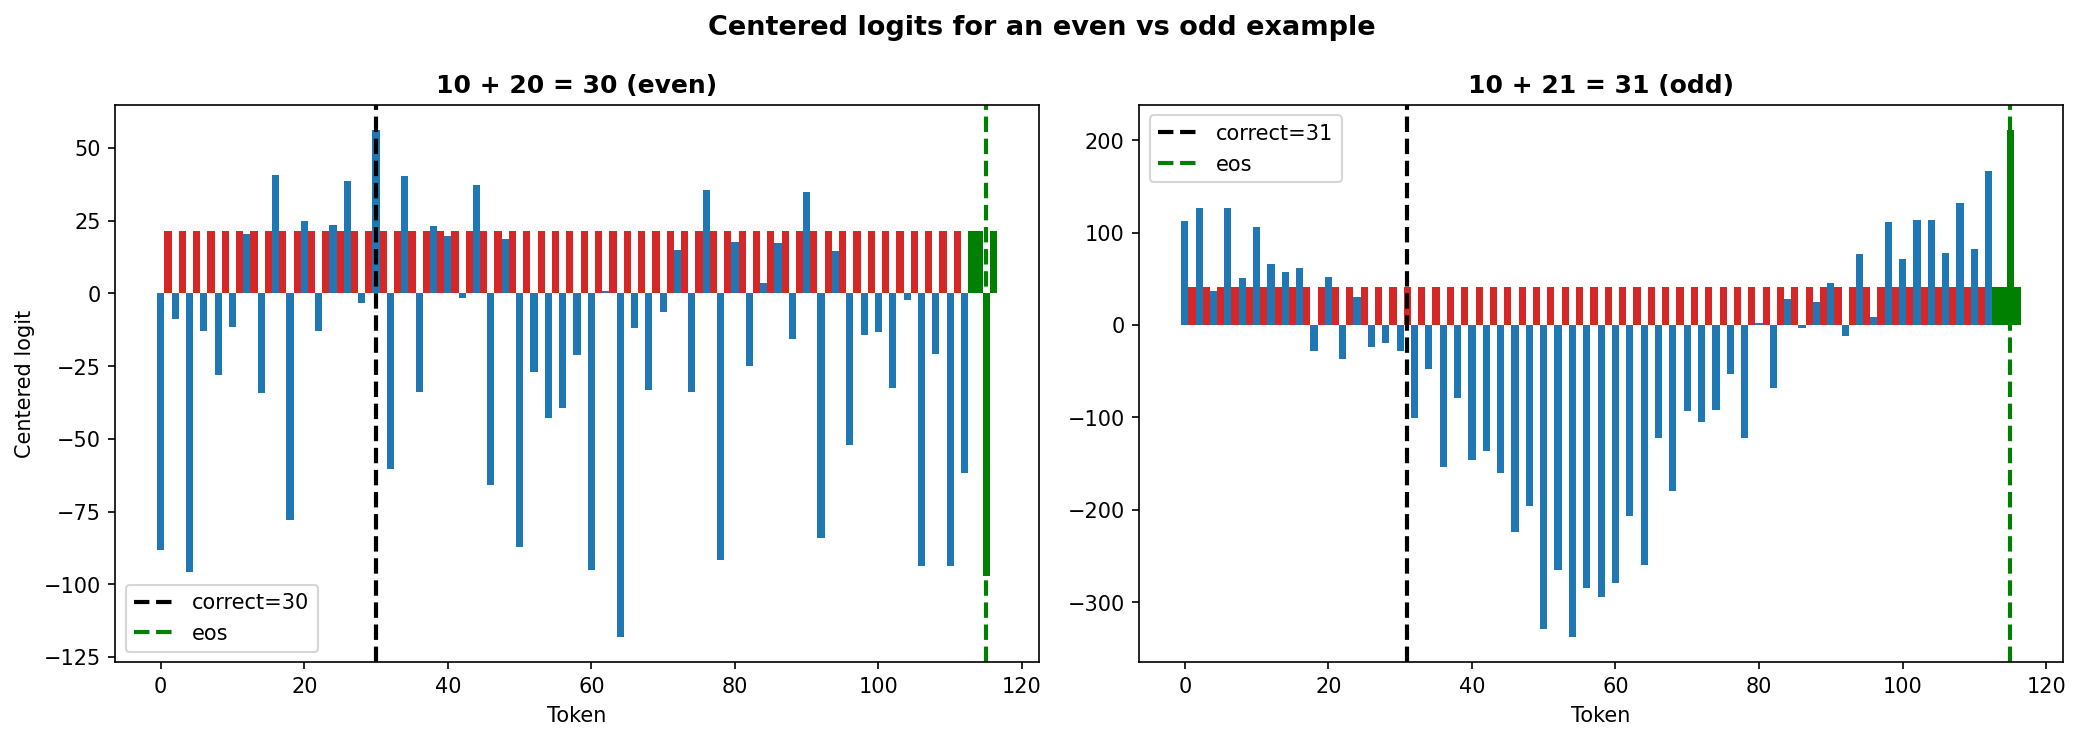

In [30]:

# So odd tokens have +36 DC and even tokens have -38 DC.
# But even tokens have 4.8x larger sin(56(a+b)) swing.
# Let's see: for an even token at the correct answer, what's the total logit?

# For even token t at correct input (a+b)%p = t:
# logit ≈ DC_even + |A_even| (peak of cosine ≈ 1)
# ≈ -38 + 92 = +54

# For odd token t at any input:
# logit ≈ DC_odd + tiny oscillation
# ≈ +36 ± 19

# For EOS at odd (a+b):
# logit ≈ DC_eos + A_eos * sin(56(a+b)) + cos(a+b) term
# ≈ 69 + 250 * sin(56(a+b)) + 34 * cos(a+b)

# Let's verify: plot logits for a specific even and odd example
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Even example: a=10, b=20, (a+b)%113 = 30 (even)
idx_even = 10 * p + 20
logits_even = logits_centered[idx_even].numpy()
axes[0].bar(range(117), logits_even, width=1, 
            color=['tab:blue' if t%2==0 and t<p else 'tab:red' if t<p else 'green' for t in range(117)])
axes[0].axvline(30, color='black', linestyle='--', linewidth=2, label=f'correct=30')
axes[0].axvline(115, color='green', linestyle='--', linewidth=2, label='eos')
axes[0].set_title(f"10 + 20 = 30 (even)", fontweight="bold")
axes[0].set_xlabel("Token")
axes[0].set_ylabel("Centered logit")
axes[0].legend()

# Odd example: a=10, b=21, (a+b)%113 = 31 (odd)
idx_odd = 10 * p + 21
logits_odd = logits_centered[idx_odd].numpy()
axes[1].bar(range(117), logits_odd, width=1,
            color=['tab:blue' if t%2==0 and t<p else 'tab:red' if t<p else 'green' for t in range(117)])
axes[1].axvline(31, color='black', linestyle='--', linewidth=2, label=f'correct=31')
axes[1].axvline(115, color='green', linestyle='--', linewidth=2, label='eos')
axes[1].set_title(f"10 + 21 = 31 (odd)", fontweight="bold")
axes[1].set_xlabel("Token")
axes[1].legend()

fig.suptitle("Centered logits for an even vs odd example", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figs/logit_examples_even_odd.png", dpi=150, bbox_inches="tight")
ipy_display(IPImage(filename="outputs/figs/logit_examples_even_odd.png"))


In [31]:

# Collect the tables I need for the document

# 1. Centered logits, averaged across number tokens
df_centered_doc = decompose_to_sum_basis_v2(coeff_avg_centered, p, freq_names)
df_centered_doc = df_centered_doc[df_centered_doc["Component"] != "DC"].head(15)
centered_table = df_centered_doc[["Component", "Coefficient", "|Coeff|"]].copy()
centered_table["Coefficient"] = centered_table["Coefficient"].map(lambda x: f"{x:.2f}")
centered_table["|Coeff|"] = centered_table["|Coeff|"].map(lambda x: f"{x:.2f}")
print("=== Table 1: Centered logits (avg across number tokens) ===")
print(centered_table.to_markdown())

# 2. Per-token: even token example (t=10), odd token (t=11), EOS
print("\n=== Table 2: Per-token decomposition ===")
for t, label in [(10, "even token t=10"), (11, "odd token t=11"), (115, "EOS token")]:
    if t < p:
        ft_t = ft_per_token[t]
    else:
        ft_t = fourier_transform_2d(
            logits_centered_vpp[t:t+1], fourier_basis=fb_cpu
        )[0]
    df_t = decompose_to_sum_basis_v2(ft_t, p, freq_names)
    df_t = df_t.head(5)
    df_t["Coefficient"] = df_t["Coefficient"].map(lambda x: f"{x:.2f}")
    df_t["|Coeff|"] = df_t["|Coeff|"].map(lambda x: f"{x:.2f}")
    print(f"\n{label}:")
    print(df_t[["Component", "Coefficient"]].to_markdown())

# 3. DC and sin56 stats
print(f"\n=== Stats ===")
print(f"DC: even tokens mean={even_dc.mean():.2f}, odd tokens mean={odd_dc.mean():.2f}")
print(f"|sin(56(a+b))| coeff: even tokens mean={even_sin56.mean():.2f}, odd tokens mean={odd_sin56.mean():.2f}")
print(f"Probe accuracy: all={best_info['acc']:.4f}, even={best_info['even']:.4f}, odd={best_info['odd']:.4f}")


=== Table 1: Centered logits (avg across number tokens) ===
|   Rank | Component      |   Coefficient |   |Coeff| |
|-------:|:---------------|--------------:|----------:|
|      1 | sin(56a + 56b) |         -2.72 |      2.72 |
|      3 | cos(1a + 1b)   |         -0.39 |      0.39 |
|      4 | cos(56a - 56b) |         -0.27 |      0.27 |
|      5 | sin(1b)        |          0.16 |      0.16 |
|      6 | sin(1a)        |          0.16 |      0.16 |
|      7 | sin(55a + 55b) |          0.12 |      0.12 |
|      8 | cos(1a - 1b)   |          0.1  |      0.1  |
|      9 | cos(56a + 55b) |          0.1  |      0.1  |
|     10 | cos(55a + 56b) |          0.1  |      0.1  |
|     11 | sin(56a + 1b)  |          0.08 |      0.08 |
|     12 | sin(1a + 56b)  |          0.08 |      0.08 |
|     13 | sin(55a - 56b) |          0.08 |      0.08 |
|     14 | sin(56a - 55b) |         -0.08 |      0.08 |
|     15 | cos(55b)       |          0.07 |      0.07 |
|     16 | cos(55a)       |          0.07 | 


odd token t=11:
|   Rank | Component      |   Coefficient |
|-------:|:---------------|--------------:|
|      1 | DC             |         35.93 |
|      2 | sin(56a + 56b) |         19.21 |
|      3 | cos(56a - 56b) |          3.74 |
|      4 | cos(1a + 1b)   |          3.51 |
|      5 | sin(1b)        |         -3.45 |

EOS token:
|   Rank | Component      |   Coefficient |
|-------:|:---------------|--------------:|
|      1 | sin(56a + 56b) |        250.26 |
|      2 | DC             |         69.49 |
|      3 | cos(1a + 1b)   |         33.71 |
|      4 | cos(56a - 56b) |         19.64 |
|      5 | sin(55a + 55b) |        -10.31 |

=== Stats ===
DC: even tokens mean=-38.41, odd tokens mean=35.93
|sin(56(a+b))| coeff: even tokens mean=92.16, odd tokens mean=19.21
Probe accuracy: all=0.9953, even=1.0000, odd=0.9903


In [32]:

# Sample 8 tokens: mix of even, odd, and EOS
sample_tokens = [0, 1, 10, 11, 56, 57, 112, tokenizer.eos_token_id]

for t in sample_tokens:
    if t < p:
        ft_t = ft_per_token[t]
        label = f"token {t} ({'even' if t%2==0 else 'odd'})"
    else:
        ft_t = fourier_transform_2d(
            logits_centered_vpp[t:t+1], fourier_basis=fb_cpu
        )[0]
        label = f"<eos> (token {t})"
    
    df_t = decompose_to_sum_basis_v2(ft_t, p, freq_names)
    df_t = df_t.head(20)
    df_t["Coefficient"] = df_t["Coefficient"].map(lambda x: f"{x:.2f}")
    df_t["|Coeff|"] = df_t["|Coeff|"].map(lambda x: f"{x:.2f}")
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    display(df_t)



  token 0 (even)


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),148.06,148.06
2,DC,41.17,41.17
3,cos(32a + 32b),37.92,37.92
4,cos(1a + 1b),20.58,20.58
5,cos(56a - 56b),12.29,12.29
6,sin(32a + 32b),8.34,8.34
7,sin(55a + 55b),-6.37,6.37
8,sin(1b),-6.10,6.10
9,sin(1a),-5.98,5.98



  token 1 (odd)


,Component,Coefficient,|Coeff|
Rank,,,
1,DC,35.93,35.93
2,sin(56a + 56b),19.21,19.21
3,cos(56a - 56b),3.74,3.74
4,cos(1a + 1b),3.51,3.51
5,sin(1b),-3.45,3.45
6,sin(1a),-3.44,3.44
7,sin(55a + 55b),-1.17,1.17
8,sin(56a + 1b),-1.11,1.11
9,sin(1a + 56b),-1.11,1.11



  token 10 (even)


...

,Component,Coefficient,|Coeff|
Rank,,,
1,DC,35.93,35.93
2,sin(56a + 56b),19.21,19.21
3,cos(56a - 56b),3.74,3.74
4,cos(1a + 1b),3.51,3.51
5,sin(1b),-3.45,3.45
6,sin(1a),-3.44,3.44
7,sin(55a + 55b),-1.17,1.17
8,sin(56a + 1b),-1.11,1.11
9,sin(1a + 56b),-1.11,1.11



  token 112 (even)


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),152.82,152.82
2,sin(32a + 32b),-48.99,48.99
3,DC,31.40,31.40
4,cos(32a + 32b),-21.54,21.54
5,cos(1a + 1b),21.14,21.14
6,cos(56a + 56b),-13.50,13.50
7,cos(56a - 56b),13.06,13.06
8,sin(55a + 55b),-6.47,6.47
9,cos(1a - 1b),-5.75,5.75



  <eos> (token 115)


,Component,Coefficient,|Coeff|
Rank,,,
1,sin(56a + 56b),250.26,250.26
2,DC,69.49,69.49
3,cos(1a + 1b),33.71,33.71
4,cos(56a - 56b),19.64,19.64
5,sin(55a + 55b),-10.31,10.31
6,cos(56a + 55b),-9.37,9.37
7,cos(55a + 56b),-9.36,9.36
8,cos(1a - 1b),-9.21,9.21
9,sin(1b),-8.16,8.16
